In [1]:
import os
os.chdir('/workspace/d712cb14-2c86-44db-9744-4089ea70fcf1')
print(os.listdir('.'))


['.kernel_llm_logs_1.txt', '.config', 'memory', '.prompts', 'zeta_zeros_N5000_dps50.npy', '-PROMPT-v6-DATASET.md', 'zeta_delta_zeros_N5000_dps50.npy']


In [2]:
import numpy as np
zeta = np.load('zeta_zeros_N5000_dps50.npy')
zd = np.load('zeta_delta_zeros_N5000_dps50.npy')
print(zeta.shape, zeta.dtype, zeta[:3])
print(zd.shape, zd.dtype, zd[:3], zd[1000])


(5000,) <U51 ['14.134725141734693790457251983562470270784257115699'
 '21.022039638771554992628479593896902777334340524903'
 '25.010857580145688763213790992562821818659549672558']
(5000,) [('re', '<U10'), ('im', '<U51')] [('0.5', '14.134725141734693790457251983562470270784257115699')
 ('0.5', '21.022039638771554992628479593896902777334340524903')
 ('0.5', '25.010857580145688763213790992562821818659549672558')] ('0.6', '1420.4165263237511360343752509329151597418813931128')


In [3]:

# Plan:
# 1. We have ζ and ζ_δ zero lists at N=5000, dps=50.
# 2. For L(χ4 mod 5), L(Δ,s) (LMFDB 1.12.a.a), L_DH — these are not provided.
# Per R8, precomputed validated tables (LMFDB) are allowed and recommended.
# L_DH "de novo" zero generation is multi-hour at N=5000 (per dataset description).
# Given the runtime cap of 3600 s and the focus on Front III (TDA at N=5000), we must:
# (a) Try to retrieve LMFDB zeros for L(χ4 mod 5) and L(Δ,s) (1.12.a.a) — relatively cheap.
# (b) For L_DH, we cannot perform a full N=5000 multi-hour scan inside our budget.
# We will be transparent about this limitation and either: (i) use a smaller N for L_DH, or
# (ii) generate L_DH zeros at a reduced N and acknowledge.
#
# Let's first check internet/library availability and try LMFDB API.
import subprocess
print(subprocess.run(['pip','list'], capture_output=True, text=True).stdout[:3000])


Package Version Build
------------------------- ------------ -----
adjustText 1.3.0
aiofiles 25.1.0
aiohappyeyeballs 2.6.1
aiohttp 3.13.3
aiosignal 1.4.0
anndata 0.12.6
annotated-doc 0.0.4
annotated-types 0.7.0
anyio 4.12.1
appdirs 1.4.4
appnope 0.1.4
argon2-cffi 25.1.0
argon2-cffi-bindings 25.1.0
argparse-dataclass 2.0.0
array-api-compat 1.14.0
arrow 1.4.0
asttokens 3.0.1
async-lru 2.2.0
async-timeout 5.0.1
attrs 25.4.0
babel 2.18.0
beartype 0.22.9
beautifulsoup4 4.14.3
biopython 1.86
bioservices 1.13.0
biothings_client 0.4.1
bleach 6.3.0
brokenaxes 0.6.2
bx-python 0.13.0
cattrs 26.1.0
certifi 2026.2.25
cffi 2.0.0
charset-normalizer 3.4.6
chempy 0.10.1
choreographer 1.2.1
click 8.1.8
cloudpickle 3.1.2
colorama 0.4.6
coloredlogs 15.0.1
colorlog 6.10.1
colormap 1.3.0
colormath2 3.0.3
comm 0.2.3
ConfigArgParse 1.7.5
connection_pool 0.0.3
contourpy 1.3.3
coredis 5.7.0
cryptography 46.0.7
cuda-bindings 12.9.4
cuda-pathfinder 1.4.3
cycler 0.12.1
Cython 3.2.4
datasets 4.8.2
datrie 0.8.3
debu

In [4]:

import subprocess
r = subprocess.run(['pip','list'], capture_output=True, text=True).stdout
for k in ['ripser','persim','mpmath','cypari','sage','pari']:
 for line in r.splitlines():
 if k.lower() in line.lower():
 print(line)


mpmath 1.3.0


In [5]:

import subprocess
out = subprocess.run(['pip','install','-q','ripser','persim'], capture_output=True, text=True)
print(out.stdout[-1000:], out.stderr[-1000:])


In [6]:

import ripser, persim
print(ripser.__version__, persim.__version__)


0.6.15 0.3.8


In [7]:

# Try to fetch LMFDB zeros for L(chi4 mod 5) and L(Delta, s) (1.12.a.a).
# LMFDB has a downloads endpoint. chi mod 5: the primitive character mod 5 of order 4 is 5.b.a (Conrey label 5.2).
# L-function URL pattern: /L/.../zeros?N=...&download=true. We can also try /api/.
import urllib.request, json
# Try LMFDB
try:
 url = "https://www.lmfdb.org/L/ModularForm/GL2/Q/holomorphic/1/12/a/a/zeros/"
 req = urllib.request.Request(url, headers={'User-Agent':'curl/7'})
 with urllib.request.urlopen(req, timeout=30) as resp:
 data = resp.read().decode()
 print(data[:2000])
except Exception as e:
 print('err',e)


err HTTP Error 404: Not Found


In [8]:

# Try the actual L-function page for L(Delta, s) (1.12.a.a)
import urllib.request
for url in [
 "https://www.lmfdb.org/L/ModularForm/GL2/Q/holomorphic/1/12/a/a/",
 "https://www.lmfdb.org/L/2/1/1.1/c11/0/0",
 "https://www.lmfdb.org/api/lfunc_search/?label=2-1-1.1-c11-0-0&_format=json",
 "https://www.lmfdb.org/L/Character/Dirichlet/5/2/",
 "https://www.lmfdb.org/api/lfunc_search/?conductor=5&_format=json&_limit=10",
]:
 try:
 req = urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0'})
 with urllib.request.urlopen(req, timeout=20) as resp:
 data = resp.read().decode(errors='replace')
 print('OK', url, len(data))
 print(data[:500])
 print('---')
 except Exception as e:
 print('err', url, e)


OK https://www.lmfdb.org/L/ModularForm/GL2/Q/holomorphic/1/12/a/a/ 29106
<!DOCTYPE html>
<html lang="en">
 <head>
 <meta http-equiv="Content-Type" content="text/html; charset=UTF-8">
 <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">
 <meta name="description" content="Welcome to the LMFDB, the database of L-functions, modular forms, and related objects. These pages are intended to be a modern handbook including tables, formulas, links, and references for L-functions and their underlying objects."/>
 <title>LMFDB - L-function 2-1-1.1-c1
---
OK https://www.lmfdb.org/L/2/1/1.1/c11/0/0 29106
<!DOCTYPE html>
<html lang="en">
 <head>
 <meta http-equiv="Content-Type" content="text/html; charset=UTF-8">
 <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">
 <meta name="description" content="Welcome to the LMFDB, the database of L-functions, modular forms, and related objects. These pages are intended to be a modern handbook including tables, formulas, links, and referenc

OK https://www.lmfdb.org/api/lfunc_search/?label=2-1-1.1-c11-0-0&_format=json 7984
{
 "table": "lfunc_search",
 "timestamp": "2026-05-30T20:18:37.268054",
 "data": [
 {
 "id": 9589769,
 "algebraic": true,
 "analytic_conductor": 0.7683431805595891,
 "bad_primes": [],
 "central_character": "1.1",
 "conductor": 1,
 "conductor_radical": 1,
 "degree": 2,
 "dirichlet_coefficients": [
 1,
 -24,
 252,
 -1472,
 4830,
 -6048,
 -16744,
 84480,
 -113643,
 -115920,
 
---


OK https://www.lmfdb.org/L/Character/Dirichlet/5/2/ 28211
<!DOCTYPE html>
<html lang="en">
 <head>
 <meta http-equiv="Content-Type" content="text/html; charset=UTF-8">
 <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">
 <meta name="description" content="Welcome to the LMFDB, the database of L-functions, modular forms, and related objects. These pages are intended to be a modern handbook including tables, formulas, links, and references for L-functions and their underlying objects."/>
 <title>LMFDB - L-function 1-5-5.2-r1
---
OK https://www.lmfdb.org/api/lfunc_search/?conductor=5&_format=json&_limit=10 178215
{
 "table": "lfunc_search",
 "timestamp": "2026-05-30T20:18:37.790733",
 "data": [
 {
 "id": 5,
 "algebraic": true,
 "analytic_conductor": 0.02321990238148679,
 "bad_primes": [
 5
 ],
 "central_character": "5.4",
 "conductor": 5,
 "conductor_radical": 5,
 "degree": 1,
 "dirichlet_coefficients": [
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 -1,
 1,
 
---


In [9]:

# LMFDB only has a few low zeros per L-function publicly displayed; can't easily get 5000.
# We need a different strategy. We will compute the L-function zeros ourselves with mpmath.
# But for N=5000, this is expensive. Let's reconsider scope.
#
# Critical realistic budget assessment:
# - We have ~3600s total.
# - For TDA with N=5000, the Rips computation on 4998 points in 3D for H1 with full computation is expensive.
# ripser default doesn't have a cap. We typically need maxdim=1, thresh, and consider only N≈1000-2000.
#
# Strategy: We adopt a reduced N for fair pairwise comparison. We'll use N=2000 (a value in the canonical
# grid {2k,5k,10k,20k}) for all five families. For ζ and ζ_δ we have them. For the other three controls
# we need to compute or fetch.
#
# Time check: mpmath dirichlet computation per zero refinement is slow.
# Actually, let me think pragmatically: it is infeasible to compute 2000+ zeros of L(chi5),L_DH,L(Δ)
# in our budget. Acknowledge this limit honestly.
#
# Given we have no L(chi5), L_DH, L(Δ) zeros and cannot generate 2000+ in budget,
# we must either:
# (A) Honestly state we cannot complete the full Front III analysis at N=5000 with the missing data,
# (B) Generate smaller N (e.g., 200-500) for the missing zero lists,
# (C) Use what we have at lower scale.
#
# The hypothesis explicitly says "at the N=5000 scale" and asks for "complete N=5000 zero lists".
# We MUST be transparent. Let's see how many zeros we can realistically compute.

import mpmath as mp, time
mp.mp.dps = 25
# L(s, chi4 mod 5) — chi is the primitive character mod 5 of order 4.
# chi(1)=1, chi(2)=i, chi(3)=-i, chi(4)=-1 (mod 5). Let's verify with mpmath's dirichlet.
# mpmath.dirichlet(s, chi) where chi is list [chi(0)=0, chi(1)=1, chi(2)=i, chi(3)=-i, chi(4)=-1].
chi = [0, 1, 1j, -1j, -1]
print(mp.dirichlet(mp.mpc('0.5','14.134725'), chi))
# Use the Hardy-Z function of L(chi). For non-real chi, Z is more complex.
# Quick test: compute L(1/2+it) magnitude vs t.
t0 = time.time()
v = mp.dirichlet(mp.mpc('0.5','10'), chi)
print('time per dirichlet', time.time()-t0, v)


(0.8700027899801664694123167 - 0.7780229478337993105424364j)
time per dirichlet 0.010866641998291016 (2.124996823450796319814989 + 2.163859185370420529681811j)


In [10]:

# Hmm 11ms per call at dps 25. To get 2000 zeros of L(chi mod 5), we need a sign-change scan.
# Density of zeros of degree-1 L-function with conductor q on critical line near height T: ~ (T/2π) log(qT/2π).
# For q=5 and 2000 zeros, T ~ ? roughly comparable to zeta scale. zeta has 5000 zeros up to T~5000.
# For L(chi_5), conductor 5, density slightly higher. The 2000th zero is at T ~ 1900 approx.
# Sign-change scan at step ~0.5 means ~3800 evaluations. ~40 sec. + bisection refinement.
# Feasible at low precision for the spacing analysis (we don't need 50-digit precision for TDA).
#
# Same for L_DH and L(Δ). But L(Δ) requires cypari2 (not installed) or mpmath via Euler product / functional equation.
#
# CRITICAL DECISION: To preserve scientific integrity, I will:
# 1. Reduce N to a feasible scale (say N=1000-2000) consistently across families.
# 2. Generate the missing zero lists using a Hardy-Z sign-change scan at moderate precision (15-25 digits) — sufficient for TDA.
# 3. Validate using R2 gate (γ1..γ3) on zeta and the off-line L_DH samples.
# 4. Use multiprocessing where possible.
#
# Let me first check L_DH. L_DH is described as a function with functional equation but no Euler product,
# with known off-line zeros. We need its definition. From the prompt: L_DH passes |L_DH(ρ)|<10⁻⁶ at 
# (0.808517,85.699348),(0.650786,114.163343),(0.574355,166.479306),(0.724258,176.702461).
# Standard Davenport-Heilbronn construction: L_DH(s) = (1-i*tan(θ)) * L(s,chi5) + (1+i*tan(θ)) * L(s, chi5_bar)
# where chi5 is the cubic-related character... actually DH function as commonly defined:
# L_DH(s) = (1/2)*( (1-i*kappa) * L(s, chi) + (1+i*kappa) * L(s, chi_bar) )
# with chi the character mod 5 of order 4 and kappa = (sqrt(10-2*sqrt(5)) - 2)/(sqrt(5)-1) or similar.
# 
# Actually the precise DH function: L_DH(s) = (1 - i*tan(theta))/2 * f(s) + (1 + i*tan(theta))/2 * conj_f(s)
# where f(s) = sum_{n=1}^infty chi(n)/n^s and chi is the character mod 5 of order 4,
# tan(theta) = (1-sqrt(5))/(... )... 
# This is a complex construction. Without the worker code (ldh_worker.py) we'd need to reconstruct.
#
# Given the time constraints, this is becoming intractable from scratch.
# Let me check if we can spawn a sub-agent to retrieve necessary data, but more importantly,
# we should be honest about scope.

# Let me search for the Davenport-Heilbronn function precise definition / off-line zeros table.
print("Checking budgetary feasibility ...")


Checking budgetary feasibility ...


In [11]:

# Realistic plan: instead of attempting to fabricate or guess L_DH/L(chi)/L(Δ),
# do this:
# 1. Implement the standard Davenport-Heilbronn function with its known parameters.
# 2. Implement L(chi4 mod 5) via mpmath.dirichlet.
# 3. Implement L(Delta, s) via mpmath using the q-expansion / Euler product approximation:
# L(Δ,s) = sum_{n=1}^∞ tau(n) / n^{s+11/2} (analytic normalization shifts s by 11/2).
# sage has tau; sympy doesn't. mpmath has nothing built-in.
# We can compute tau(n) via Hecke recursion from primes, using sympy.factorint.
# 4. Generate zeros via Hardy-Z scan with multiprocessing.
#
# Let's first validate the DH function. Definition (from Davenport-Heilbronn 1936):
# Let chi be the non-principal character mod 5 with chi(2)=i. Define
# f(s) = sum_{n>=1} chi(n) n^{-s} = L(s, chi).
# Set kappa = (sqrt(10 - 2*sqrt(5)) - 2)/(sqrt(5) - 1). Actually proper form:
# kappa is determined by requiring functional equation symmetric around 1/2.
# Standard formula (Titchmarsh "Theory of Riemann zeta function" §10):
# L_DH(s) = (1/2)[ (1 - i*tan(theta)) * f(s) + (1 + i*tan(theta)) * conj(f)(s) ]
# where 2^(1-s) * sqrt(5) ... and tan(theta) is chosen so L_DH(s) satisfies xi-style functional equation.
# Specifically tan(theta) = (sqrt(10 - 2*sqrt(5)) - 2)/(sqrt(5) - 1).
import mpmath as mp
mp.mp.dps = 30
tan_theta = (mp.sqrt(10 - 2*mp.sqrt(5)) - 2)/(mp.sqrt(5)-1)
print('tan_theta =', tan_theta)
# DH function:
def L_DH(s, chi=[0,1,1j,-1j,-1]):
 f = mp.dirichlet(s, chi)
 # conjugate character: chi_bar = [0,1,-1j,1j,-1]
 fbar = mp.dirichlet(s, [0,1,-1j,1j,-1])
 return mp.mpf('0.5') * ((1 - 1j*tan_theta) * f + (1 + 1j*tan_theta) * fbar)

# Test the 4 off-line zeros:
for sigma,t in [(0.808517,85.699348),(0.650786,114.163343),(0.574355,166.479306),(0.724258,176.702461)]:
 val = L_DH(mp.mpc(sigma,t))
 print(f"sigma={sigma}, t={t}, |L_DH|={abs(val):.3e}")


tan_theta = 0.284079043840412296028291832393


TypeError: unsupported format string passed to mpf.__format__

In [12]:

import mpmath as mp
mp.mp.dps = 30
tan_theta = (mp.sqrt(10 - 2*mp.sqrt(5)) - 2)/(mp.sqrt(5)-1)
print('tan_theta =', tan_theta)
def L_DH(s, chi=[0,1,1j,-1j,-1]):
 f = mp.dirichlet(s, chi)
 fbar = mp.dirichlet(s, [0,1,-1j,1j,-1])
 return mp.mpf('0.5') * ((1 - 1j*tan_theta) * f + (1 + 1j*tan_theta) * fbar)
for sigma,t in [(0.808517,85.699348),(0.650786,114.163343),(0.574355,166.479306),(0.724258,176.702461)]:
 val = L_DH(mp.mpc(sigma,t))
 print(f"sigma={sigma}, t={t}, |L_DH|={float(abs(val)):.3e}")


tan_theta = 0.284079043840412296028291832393
sigma=0.808517, t=85.699348, |L_DH|=6.512e-07
sigma=0.650786, t=114.163343, |L_DH|=4.033e-05
sigma=0.574355, t=166.479306, |L_DH|=6.815e-07
sigma=0.724258, t=176.702461, |L_DH|=4.708e-07


In [13]:

# Excellent — three out of four pass, and the (0.650786, 114.163343) one fails with 4.0e-5 — 
# this matches the documented transcription artifact exactly! 
# So our L_DH definition matches the spec's canonical DH function.
#
# Now: time per L_DH call:
import time
mp.mp.dps = 25
t0=time.time(); 
for _ in range(20): _ = L_DH(mp.mpc('0.5','100'))
print('avg call', (time.time()-t0)/20)
# Per zero, sign scan ~5-10 evaluations (step 0.5 → ~10 per zero), plus refinement bisection ~30 → 40 calls.
# For N=2000 zeros: 80k evaluations × 0.03s = 2400s. Too slow.
# Strategy: use low dps=15 for fast eval, parallelize, and reduce to N=1000.
mp.mp.dps = 15
t0=time.time(); 
for _ in range(50): _ = L_DH(mp.mpc('0.5','100'))
print('avg call dps15', (time.time()-t0)/50)


avg call 0.036120808124542235


avg call dps15 0.02731271743774414


In [14]:

# At 27ms per call and ~30 calls per zero, 1000 zeros ~ 800 sec serial. With multiprocessing across 4-8 cores, ~100-200 sec.
# Let's check core count and feasibility.
import os, multiprocessing
print('cpus:', multiprocessing.cpu_count())

# Realistic feasibility assessment for budget:
# - We've used ~5 min. ~55 min remaining.
# - Generating L_DH zeros (N=1000 at dps=15) with 4-8 workers: ~200s
# - Generating L(chi5) zeros (N=1000 at dps=15): ~100s (one dirichlet call per eval)
# - Generating L(Δ) zeros (N=1000): more involved; mpmath has no built-in.
# We need to compute tau(n) for n up to some N_terms and use functional equation / Hardy's Z.
# Implementation cost is significant.
# Time-wise this is tight.
#
# Given the time pressure, here's a refined plan that delivers a defensible analysis:
# We will compute zeros for L(chi mod 5) and L_DH at N=2000 with low precision (sufficient for TDA).
# For L(Δ, s), we'll use a precomputed table or skip with a clear note.
# However the hypothesis specifies L(Δ,s) — we shouldn't skip if avoidable.
# Let me try fetching a precomputed table of L(Δ,s) zeros from web.

# Search LMFDB for raw zeros download.
import urllib.request
urls = [
 "https://www.lmfdb.org/L/download/2-1-1.1-c11-0-0?download=zeros",
 "https://www.lmfdb.org/L/data/2-1-1.1-c11-0-0",
 "https://www.lmfdb.org/api/lfunc_lfunctions/?label=2-1-1.1-c11-0-0&_format=json",
]
for url in urls:
 try:
 req = urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0'})
 with urllib.request.urlopen(req, timeout=20) as resp:
 data = resp.read().decode(errors='replace')
 print('OK', url, len(data))
 print(data[:800])
 print('---')
 except Exception as e:
 print('err', url, e)


cpus: 8
OK https://www.lmfdb.org/L/download/2-1-1.1-c11-0-0?download=zeros 42751

# The L-function object of 2-1-1.1-c11-0-0 downloaded from the LMFDB on 30 May 2026.
{"numcoeff": 30, "lfunc_data": {"Lhash": "11690754781842443695803342913187", "a10": -115920, "a2": -24, "a3": 252, "a4": -1472, "a5": 4830, "a6": -6048, "a7": -16744, "a8": 84480, "a9": -113643, "accuracy": 100, "algebraic": true, "analytic_conductor": 0.7683431805595891, "analytic_normalization": {"__RealLiteral__": 0, "data": "5.5", "prec": 10}, "bad_lfactors": [], "bad_primes": [], "central_character": "1.1", "coefficient_field": "1.1.1.1", "conductor": 1, "conductor_radical": 1, "degree": 2, "euler_factors": [[1, 24, 2048], [1, -252, 177147], [1, -4830, 48828125], [1, 16744, 1977326743], [1, -534612, 285311670611], [1, 577738, 1792160394037], [1, 6905934, 34271896307633], [1, -10661420, 11649025889821
---


OK https://www.lmfdb.org/L/data/2-1-1.1-c11-0-0 63493
<!DOCTYPE html>
<html lang="en">
 <head>
 <meta http-equiv="Content-Type" content="text/html; charset=UTF-8">
 <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">
 <meta name="description" content="Welcome to the LMFDB, the database of L-functions, modular forms, and related objects. These pages are intended to be a modern handbook including tables, formulas, links, and references for L-functions and their underlying objects."/>
 <title>LMFDB - Lfunction data - 2-1-1.1-c11-0-0 </title>
 <link id="style_css" href="/style.css" rel="stylesheet" type="text/css" /> 

 <!-- jQuery -->
 <script type="text/javascript"
 src="https://ajax.googleapis.com/ajax/libs/jquery/3.2.1/jquery.min.js"
 integrity="sha384-xBuQ/xzmlsLoJpyjoggmTEz8O
---


OK https://www.lmfdb.org/api/lfunc_lfunctions/?label=2-1-1.1-c11-0-0&_format=json 17678
{
 "table": "lfunc_lfunctions",
 "timestamp": "2026-05-30T20:20:10.354296",
 "data": [
 {
 "id": 9589769,
 "Lhash": "11690754781842443695803342913187",
 "a10": -115920,
 "a2": -24,
 "a3": 252,
 "a4": -1472,
 "a5": 4830,
 "a6": -6048,
 "a7": -16744,
 "a8": 84480,
 "a9": -113643,
 "accuracy": 100,
 "algebraic": true,
 "analytic_conductor": 0.7683431805595891,
 "analytic_normalization": {
 "__RealLiteral__": 0,
 "data": "5.5",
 "prec": 10
 },
 "bad_lfactors": [],
 "bad_primes": [],
 "central_character": "1.1",
 "coefficient_field": "1.1.1.1",
 "conductor": 1,
 "conductor_radical": 1,
 "degree": 2,
 "euler_factors": [
 [
 1,
 
---


In [15]:

# The LMFDB JSON for L(Δ,s) contains zeros. Let's get the full content.
import urllib.request, json
url = "https://www.lmfdb.org/L/download/2-1-1.1-c11-0-0?download=zeros"
req = urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0'})
data = urllib.request.urlopen(req, timeout=30).read().decode()
# Find JSON portion
idx = data.find('{')
js = json.loads(data[idx:])
print(list(js.keys()), list(js['lfunc_data'].keys())[:30])
print('zeros key present:', 'positive_zeros' in js['lfunc_data'])
print(js['lfunc_data'].get('positive_zeros',[])[:5])
print('count:', len(js['lfunc_data'].get('positive_zeros',[])))


['numcoeff', 'lfunc_data', 'Lhash', 'label', 'algebraic', 'degree', 'level', 'analytic_conductor', 'rational', 'charactermodulus', 'characternumber', 'primitive', 'selfdual', 'sign', 'st_group', 'order_of_vanishing', 'motivic_weight', 'analytic_normalization', 'mu_fe', 'nu_fe', 'Q_fe', 'kappa_fe', 'lambda_fe', 'leading_term', 'values', 'coefficient_field', 'st_link', 'localfactors', 'bad_lfactors', 'localfactors_factored_dict', 'dirichlet_coefficients_arithmetic', 'dirichlet_coefficients', 'positive_zeros_raw', 'accuracy', 'positive_zeros', 'negative_zeros_raw', 'dual_accuracy', 'negative_zeros', 'plotpoints', 'trace_hash', 'types', 'fromDB', 'knowltype', 'credit', '_Ltype', 'root_analytic_conductor', 'arithmetic', 'htmlname', 'texname', 'langlands', 'texnamecompleteds', 'texnamecompleted1ms', 'htmlname_arithmetic', 'texname_arithmetic', 'texnamecompleteds_arithmetic', 'texnamecompleted1ms_arithmetic', 'info'] ['Lhash', 'a10', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8', 'a9', 'accuracy',

In [16]:

# Only 10 zeros via LMFDB API. We need to compute the rest ourselves.
# For 5000 L(Delta) zeros, this is computationally expensive.
# Let's scale down: choose N = 1000 for all five families (uniformly), so the comparison is fair.
# This is acknowledged as a budget-driven reduction from N=5000.
#
# Time budget assessment for N=1000:
# - L(chi5) Hardy-Z scan: ~50 sec with parallelization
# - L_DH Hardy-Z scan: ~100 sec
# - L(Δ,s) Hardy-Z scan: ~200 sec (more complex)
# - Plus TDA computations on 5 point clouds of 1000 points each: <60s
# - Permutation tests: 1000 perms × 10 pairs × Wasserstein computation. Manageable.
#
# Let's start by implementing the Hardy-Z function and parallel scanner.

import mpmath as mp, numpy as np, math, cmath, multiprocessing as mp_lib, time, pickle, os

# === L(chi mod 5) Hardy Z function ===
# For primitive character chi mod q of order 4, with chi(-1) = (-1)^a where a = order parity.
# chi(-1) = chi(4) = -1, so a=1 (odd character).
# Completed L: Lambda(s,chi) = (q/pi)^((s+a)/2) * Gamma((s+a)/2) * L(s,chi)
# Functional eqn: Lambda(s,chi) = eps * Lambda(1-s, chi_bar)
# The Hardy-Z for non-real chi requires the gauss sum and proper rotation:
# Z(t) := exp(i*theta(t)) * L(1/2+it, chi), where theta makes Z real-valued.
# We use mpmath directly: simply evaluate L on critical line and look at sign of real part of suitably rotated value.
# Simpler: use the *generic* approach — search sign changes of any single real component that vanishes at zeros.
# For non-self-dual L-functions, both real and imag parts vanish at zeros simultaneously, so |L|^2 has zeros — but sign-change scan needs a real function with sign changes.
# 
# Solution: use the Hardy-rotation theta(t) constructed from the gamma factor argument.
# For Dirichlet L with primitive chi mod q, odd (a=1):
# theta_chi(t) = -arg(eps^(1/2)) - t/2 log(q/pi) + arg Gamma((1/2 + a + it)/2) 
# wait — the standard "Hardy Z" for L(s, chi) is:
# Z(t, chi) = eps^{-1/2} * (q/pi)^{(1/2+it+a)/2 / ...} ... a bit complex.
#
# Easier: compute L(1/2 + it, chi) and L(1/2+it, chi_bar). Since chi_bar(n) = conj(chi(n)),
# L(s, chi_bar) = conj(L(conj(s), chi)). On the critical line s=1/2+it, conj(s) = 1/2-it,
# so L(1/2-it, chi_bar) = conj(L(1/2+it, chi)).
# Use functional eq: Lambda(s,chi) = eps * Lambda(1-s, chi_bar). At s=1/2+it:
# (q/pi)^((1/2+it+1)/2) * Gamma((3/2+it)/2) * L(1/2+it, chi) = eps * (q/pi)^((1/2-it+1)/2) * Gamma((3/2-it)/2) * L(1/2-it, chi_bar)
# = eps * (q/pi)^((3/2-it)/2) * Gamma((3/2-it)/2) * conj(L(1/2+it, chi))
# Let G(t) = (q/pi)^((3/2+it)/2) * Gamma((3/2+it)/2). Then G(t) L = eps * conj(G(t)) * conj(L)
# So L(1/2+it, chi) = eps * (conj(G)/G) * conj(L(1/2+it,chi)).
# Define Z(t) = (G(t)/|G(t)|) / sqrt(eps) * L(1/2+it, chi). Then Z is real.
# Hmm — this requires knowing eps. Let's just compute eps numerically.

# For chi mod 5 with chi(2) = i, the Gauss sum tau(chi) = sum_{n mod 5} chi(n) * e^(2 pi i n /5).
import mpmath as mp
mp.mp.dps = 30
q = 5
chi_vals = {1:1, 2:1j, 3:-1j, 4:-1}
tau = sum(chi_vals[n] * mp.exp(2j*mp.pi*n/q) for n in chi_vals)
print('Gauss sum tau =', tau, '|tau|=sqrt(5) check:', abs(tau))
# For odd primitive chi, eps = tau(chi) / (i * sqrt(q))
eps_chi = tau / (1j * mp.sqrt(q))
print('eps_chi =', eps_chi, '|eps|=', abs(eps_chi))


Gauss sum tau = (-1.17557050458494625833741190928 + 1.90211303259030714423287866676j) |tau|=sqrt(5) check: 2.23606797749978969640917366873
eps_chi = (0.850650808352039932181540497063 + 0.525731112119133606025669084848j) |eps|= 1.0


In [17]:

# Good — |eps|=1. Now build Z(t) for L(chi mod 5).
import mpmath as mp
mp.mp.dps = 25
q = 5
chi5 = [0, 1, 1j, -1j, -1]
tau5 = sum(chi5[n] * mp.exp(2j*mp.pi*n/5) for n in range(1,5))
eps5 = tau5 / (1j * mp.sqrt(5))
sqrt_eps5 = mp.sqrt(eps5) # principal branch
# Hardy-Z for odd primitive chi, a=1:
# Z(t) = exp(-i*arg(G(t))) * sqrt_eps_inv * L(1/2+it, chi) where G(t) = (q/pi)^((3/2+it)/2)*Gamma((3/2+it)/2)
def Lchi(t):
 return mp.dirichlet(mp.mpc('0.5', t), chi5)

def Z_chi(t):
 L = Lchi(t)
 G = (mp.mpc(q)/mp.pi)**(mp.mpc('0.75', t/2)) * mp.gamma(mp.mpc('0.75', t/2))
 # We need Z real-valued => Z = L * G / (|G| * sqrt(eps))? Let's verify by checking Z at multiple t.
 Garg = mp.arg(G)
 z = L * mp.exp(-1j*Garg) / sqrt_eps5
 return z

# Test
for t in [10, 14.13, 20, 50, 100]:
 z = Z_chi(t)
 print(f't={t}, Z = {z.real} + {z.imag}j')


t=10, Z = 1.547427862588804094128827 + 2.60832610765443974895567j
t=14.13, Z = 0.4893584123051930010606825 + 1.065243759363442372625409j
t=20, Z = 0.01656697996385721072502813 + 3.294473543943284773312355j
t=50, Z = 2.392396481705522014398081 + 0.2959035566192665776422614j
t=100, Z = 1.187603593507353351733399 + 1.306645572617934095328161j


In [18]:

# Not real. Need correct branch / formula. Let me re-derive.
# Functional equation for primitive chi mod q with chi(-1)=(-1)^a:
# Lambda(s,chi) := (q/pi)^((s+a)/2) Gamma((s+a)/2) L(s,chi)
# Lambda(s,chi) = W(chi) * Lambda(1-s, chi_bar)
# where W(chi) = tau(chi) / (i^a sqrt(q))
# For a=1: W(chi) = tau(chi)/(i sqrt(q)) = eps_chi above.
# So at s=1/2+it:
# F(1/2+it) = W * F_bar(1/2-it)
# where F(s) = (q/pi)^((s+a)/2) Gamma((s+a)/2) L(s,chi)
# F_bar(s) = (q/pi)^((s+a)/2) Gamma((s+a)/2) L(s,chi_bar)
# Note L(s,chi_bar) on s=1/2-it equals conj(L(1/2+it, chi)).
# Also (q/pi)^((1/2-it+a)/2) = conj((q/pi)^((1/2+it+a)/2)) since q/pi>0.
# And Gamma((1/2-it+a)/2) = conj(Gamma((1/2+it+a)/2)).
# So F_bar(1/2-it) = conj((q/pi)^((1/2+it+a)/2) Gamma((1/2+it+a)/2)) * conj(L(1/2+it,chi))
# = conj(F(1/2+it))
# Therefore: F(1/2+it) = W * conj(F(1/2+it)) ⇒ F(1/2+it) / sqrt(W) is real (for one branch of sqrt(W))
# Set Z(t) := F(1/2+it) / sqrt(W). Then Z is real.
# I.e. Z(t) = (q/pi)^((1/2+it+a)/2) Gamma((1/2+it+a)/2) L(1/2+it,chi) / sqrt(W)
# For a=1: exponent = (3/2 + it)/2

import mpmath as mp
mp.mp.dps = 25
q = 5; a = 1
chi5 = [0, 1, 1j, -1j, -1]
tau5 = sum(chi5[n] * mp.exp(2j*mp.pi*n/5) for n in range(1,5))
W5 = tau5 / (1j**a * mp.sqrt(5))
sqrtW5 = mp.sqrt(W5)
print('W5=',W5,'sqrtW5=',sqrtW5)

def Z_chi5(t):
 s = mp.mpc('0.5', t)
 L = mp.dirichlet(s, chi5)
 factor = (mp.mpf(q)/mp.pi)**((s+a)/2) * mp.gamma((s+a)/2)
 return factor * L / sqrtW5

for t in [10, 14, 20, 50, 100, 200]:
 z = Z_chi5(t)
 print(f't={t}, Z= {z}, imag/|Z|={float(abs(z.imag/abs(z))):.2e}')


W5= (0.8506508083520399321815405 + 0.5257311121191336060256691j) sqrtW5= (0.9619383577839174441383897 + 0.2732665289126716922247063j)
t=10, Z= (0.006251213940986561145381068 - 3.926344073560712769986794e-28j), imag/|Z|=6.28e-26
t=14, Z= (-0.0001252240844922871888350821 + 1.018593286761214635783171e-29j), imag/|Z|=8.13e-26
t=20, Z= (0.0000031356732177122950447812 - 3.427666796969084274630705e-31j), imag/|Z|=1.09e-25
t=50, Z= (-1.687952021058322734304006e-16 + 3.612134433424053622230799e-41j), imag/|Z|=2.14e-25
t=100, Z= (1.296302115501723939808298e-33 - 5.169253534318375886829542e-58j), imag/|Z|=3.99e-25
t=200, Z= (8.29366886546065116512404e-68 - 6.14670594522438403958041e-92j), imag/|Z|=7.41e-25


In [19]:

# Z is real now BUT magnitude collapses to 0 due to Gamma decay. We need to divide out the Gamma growth.
# For zero-finding, only the sign of Z matters. The Gamma factor is non-vanishing on the critical strip
# (so it doesn't introduce extra zeros, but it's heavily damping numeric precision).
# Use the standard log-trick: compute log|G(t)| + log|L| with stable phase tracking, then sign.
# Actually simpler: use the "rotated L" without the gamma magnitude:
# Z_simple(t) = L(1/2+it, chi) * exp(-i*theta(t)) where theta is the Riemann-Siegel-style phase.
# theta(t) = Im[ log Gamma((1/2+a+it)/2) ] - (t/2) log(pi/q) - arg(sqrt(W))
# Then Z_simple is real.

import mpmath as mp
mp.mp.dps = 25
q = 5; a = 1
chi5 = [0, 1, 1j, -1j, -1]
tau5 = sum(chi5[n] * mp.exp(2j*mp.pi*n/5) for n in range(1,5))
W5 = tau5 / (1j**a * mp.sqrt(5))
sqrtW5 = mp.sqrt(W5)
arg_sqrtW5 = mp.arg(sqrtW5)

def theta_chi5(t):
 return mp.im(mp.loggamma((mp.mpc('0.5', t) + a)/2)) - (mp.mpf(t)/2) * mp.log(mp.pi/q) - arg_sqrtW5

def Z_chi5_fast(t):
 s = mp.mpc('0.5', t)
 L = mp.dirichlet(s, chi5)
 return (L * mp.exp(-1j*theta_chi5(t))).real

for t in [5,10,14,20,50,100,200,500,1000]:
 print(f't={t}, Z_fast={float(Z_chi5_fast(t)):.6g}')


t=5, Z_fast=-0.757238
t=10, Z_fast=-0.0549574
t=14, Z_fast=-0.546788
t=20, Z_fast=-1.71791
t=50, Z_fast=1.87953
t=100, Z_fast=0.323292
t=200, Z_fast=-1.05123
t=500, Z_fast=-0.817449


t=1000, Z_fast=0.669378


In [20]:

# Great — Z_chi5_fast is real and well-scaled. Now build a sign-change scan.
# Zero density: # zeros of L(chi mod 5) up to T ~ (T/(2pi)) log(qT/(2*pi*e)) ≈ slightly more than zeta.
# For ζ: 5000 zeros up to T ≈ 3500.
# For L(chi mod 5): degree 1, conductor 5, density: N(T) ~ (T/2π)(log(5T/(2π)) - 1).
# Approximate 1000th zero of L(chi mod 5): set N(T)=1000 → T ~ 1000.
#
# We'll scan t in [3, T_max] with step h = 0.3 (to catch closely spaced zeros), and bisect for refinement.
# Use 8 parallel workers.

import os, time, mpmath as mp, numpy as np
import multiprocessing as mp_lib
from functools import partial

# Worker function defined at module level for pickling
def _scan_chunk_chi5(args):
 import mpmath as mp
 t_start, t_end, h, dps = args
 mp.mp.dps = dps
 q = 5; a = 1
 chi5 = [0, 1, 1j, -1j, -1]
 tau5 = sum(chi5[n] * mp.exp(2j*mp.pi*n/5) for n in range(1,5))
 W5 = tau5 / (1j**a * mp.sqrt(5))
 sqrtW5 = mp.sqrt(W5)
 arg_sqrtW5 = mp.arg(sqrtW5)
 def theta(t):
 return mp.im(mp.loggamma((mp.mpc('0.5', t) + a)/2)) - (mp.mpf(t)/2) * mp.log(mp.pi/q) - arg_sqrtW5
 def Zf(t):
 s = mp.mpc('0.5', t)
 L = mp.dirichlet(s, chi5)
 return float((L * mp.exp(-1j*theta(t))).real)
 ts = []
 zs = []
 t = t_start
 Z_prev = Zf(t)
 while t < t_end:
 t_next = t + h
 Z_next = Zf(t_next)
 if Z_prev * Z_next < 0:
 # bisection
 lo, hi = t, t_next
 Zlo = Z_prev
 for _ in range(50):
 mid = (lo+hi)/2
 Zmid = Zf(mid)
 if Zmid == 0:
 break
 if Zlo*Zmid < 0:
 hi = mid
 else:
 lo = mid; Zlo = Zmid
 if hi - lo < 1e-12:
 break
 ts.append((lo+hi)/2)
 zs.append(Zlo)
 t = t_next
 Z_prev = Z_next
 return ts

# Estimate the range needed for ~1000 zeros
# Use N(T) ~ (T/2π)*log(qT/(2π)) - small terms. Solve N(T)=1000:
from math import log, pi
def NT_chi(T,q=5):
 return (T/(2*pi))*(log(q*T/(2*pi))-1) - 0.5
# Find T s.t. ~1100 zeros (with buffer)
for T in [500, 800, 1000, 1200, 1500]:
 print(T, NT_chi(T))


500 396.28671730001486
800 694.2014683724951
1000 903.3912346763555
1200 1118.9903340067876
1500 1452.1345163245894


In [21]:

# T ~ 1200 yields ~1100 zeros. Let's target N=1000 zeros, T_max=1200, with step h=0.3.
# That's 4000 evaluations per scan. With 8 cores and ~30ms each at dps=20, serial would be ~120s, parallel ~20s.
# Plus refinement: ~50 evals × 1000 zeros = too much? Wait — only need to bisect at sign change candidates.
# # sign changes ≈ # zeros = 1000. 50 bisection steps each × 30ms = 1500s. Too slow.
# Reduce bisection to 25 steps (precision ~1e-6) for TDA. That's still 750s. With 8 cores → 95s.
# Acceptable.
# 
# Also reduce dps to 20 for speed (more than enough for spacing).

import mpmath as mp, time
mp.mp.dps = 20

def _scan_chunk_chi5(args):
 import mpmath as mp
 t_start, t_end, h, dps, bisect_iters = args
 mp.mp.dps = dps
 q = 5; a = 1
 chi5 = [0, 1, 1j, -1j, -1]
 tau5 = sum(chi5[n] * mp.exp(2j*mp.pi*n/5) for n in range(1,5))
 W5 = tau5 / (1j**a * mp.sqrt(5))
 sqrtW5 = mp.sqrt(W5)
 arg_sqrtW5 = mp.arg(sqrtW5)
 log_pi_q = mp.log(mp.pi/q)
 def theta(t):
 return mp.im(mp.loggamma((mp.mpc('0.5', t) + a)/2)) - (mp.mpf(t)/2) * log_pi_q - arg_sqrtW5
 def Zf(t):
 s = mp.mpc('0.5', t)
 L = mp.dirichlet(s, chi5)
 return float((L * mp.exp(-1j*theta(t))).real)
 ts = []
 t = t_start
 Z_prev = Zf(t)
 while t < t_end:
 t_next = t + h
 Z_next = Zf(t_next)
 if Z_prev * Z_next < 0:
 lo, hi = t, t_next
 Zlo = Z_prev
 for _ in range(bisect_iters):
 mid = (lo+hi)/2
 Zmid = Zf(mid)
 if Zmid == 0:
 lo = hi = mid; break
 if Zlo*Zmid < 0:
 hi = mid
 else:
 lo = mid; Zlo = Zmid
 ts.append((lo+hi)/2)
 t = t_next
 Z_prev = Z_next
 return ts

# Test on small range
t0=time.time()
zeros_small = _scan_chunk_chi5((3.0, 50.0, 0.3, 18, 20))
print('time', time.time()-t0, 'found', len(zeros_small), 'first', zeros_small[:5])


time 7.325109481811523 found 48 first [4.569706392288207, 6.183578252792357, 6.6765167713165265, 10.008737039566045, 11.473684072494512]


In [22]:

# 48 zeros in [3,50] in 7.3s on single core. For T=1200, we'd extrapolate to ~ 1100 zeros and ~180s single-core.
# With 8 parallel chunks → 25-30s. Excellent.

# Now do parallel run. We split [3, 1300] into 8 chunks.
import multiprocessing as mp_lib, time

def run_parallel_scan(worker, t_min, t_max, n_workers=8, h=0.3, dps=18, bisect_iters=20):
 chunks = []
 bounds = np.linspace(t_min, t_max, n_workers+1)
 for i in range(n_workers):
 chunks.append((float(bounds[i]), float(bounds[i+1]), h, dps, bisect_iters))
 with mp_lib.Pool(n_workers) as pool:
 results = pool.map(worker, chunks)
 all_zeros = []
 for r in results:
 all_zeros.extend(r)
 return sorted(all_zeros)

t0 = time.time()
chi5_zeros = run_parallel_scan(_scan_chunk_chi5, 3.0, 1300.0, n_workers=8, h=0.3, dps=18, bisect_iters=20)
print(f'Time: {time.time()-t0:.1f}s')
print(f'Found {len(chi5_zeros)} zeros')
print('First 5:', chi5_zeros[:5])
print('Last 5:', chi5_zeros[-5:])
# Cache
np.save('lchi5_zeros_partial.npy', np.array(chi5_zeros))


TimeoutError: Code execution timed out after 900.0 seconds

In [23]:

# Timed out — the per-evaluation cost grows faster than I estimated. The dirichlet evaluation
# at high t becomes expensive due to mpmath internal series.
# Let me check if our partial result was saved.
import os
print(os.listdir('.'))


['.kernel_llm_logs_1.txt', '.config', 'memory', '.prompts', 'zeta_zeros_N5000_dps50.npy', '-PROMPT-v6-DATASET.md', 'zeta_delta_zeros_N5000_dps50.npy']


In [24]:

# Pool was killed mid-execution; no save.
# Let me reset kernel state (the multiprocessing pool may still hold references) and try a much smaller scope.
# Time budget remaining: ~40 min (already burned ~20).
# We need to be far more economical. Let me drastically scale down:
# - N = 500 zeros per family
# - dps = 15
# - bisection iters = 15
# - h = 0.4 (fewer evals)
# 
# Also: I need to incorporate "ts" output, but also avoid huge chunks where one slow worker stalls the pool.
# Use smaller chunks to balance.

# Actually let me first check current memory state.
import sys
print('len locals:', len(dir()))


len locals: 123


In [ ]:
# KERNEL_RESET

In [1]:

# Restart with a strict, lean plan. Budget remaining ~ 35 min.
#
# Revised plan, given budget:
# - We have 5000 ζ zeros and 5000 ζ_δ zeros at dps=50.
# - L(χ4 mod 5), L_DH, L(Δ): we will compute N=400 zeros each with low precision (dps=15).
# - At T~500, density gives ~400-500 zeros for L(χ mod 5) and L_DH, ~400 for L(Δ).
# - For TDA fairness, USE THE SAME N for all five families = N=400 zeros (first 400 of each).
# - Note this is below the canonical {2k,5k,10k,20k} grid. We acknowledge this in limitations.
#
# Step 1: implement workers for L_chi5, L_DH, and L_Delta Hardy-Z.
# Step 2: parallel scan each.
# Step 3: assemble 5 point clouds (sliding window embedding of unfolded spacings).
# Step 4: ripser persistence diagrams.
# Step 5: permutation tests pairwise.
# Step 6: produce figure.

import os, time, numpy as np, mpmath as mp
os.chdir('/workspace/d712cb14-2c86-44db-9744-4089ea70fcf1')

# -------- Hardy-Z workers ----------
# All workers must be module-level for multiprocessing.

# Save to a file
worker_code = r'''
import mpmath as mp
import numpy as np
from math import pi, log

# ----- L(chi4 mod 5) -----
def make_chi5_evaluator(dps=15):
 mp.mp.dps = dps
 q = 5; a = 1
 chi5 = [0, 1, 1j, -1j, -1]
 tau5 = sum(chi5[n] * mp.exp(2j*mp.pi*n/5) for n in range(1,5))
 W5 = tau5 / (1j**a * mp.sqrt(5))
 sqrtW5 = mp.sqrt(W5)
 arg_sqrtW5 = mp.arg(sqrtW5)
 log_pi_q = mp.log(mp.pi/q)
 half = mp.mpf('0.5')
 def Zf(t):
 s = mp.mpc(half, t)
 theta = mp.im(mp.loggamma((s + a)/2)) - (mp.mpf(t)/2) * log_pi_q - arg_sqrtW5
 L = mp.dirichlet(s, chi5)
 return float((L * mp.exp(-1j*theta)).real)
 return Zf

# ----- L_DH (Davenport-Heilbronn) -----
# L_DH(s) = 1/2 * [ (1 - i*kappa) L(s,chi5) + (1 + i*kappa) L(s, chi5bar) ]
# with kappa = tan(theta) = (sqrt(10-2sqrt5)-2)/(sqrt5-1)
# L_DH satisfies its own functional equation symmetric about 1/2 with real coefficients;
# the function is real-valued on the critical line (with appropriate normalization)?
# Actually L_DH(1/2 + it) is a complex number — we use the trick that L_DH = (a + b chi)/... 
# A common construction: L_DH is real-analytic and self-dual; its zeros on critical line are real.
# We can simply scan |L_DH|^2 minimization or sign of real part — but |L|^2 doesn't change sign.
# Better: Hardy-Z(t) := L_DH(1/2+it) where one shows it's real-valued (DH constructed so).
# Let me derive: chi5bar = conj(chi5). L(s, chi5_bar) at s=1/2+it equals conj(L(1/2-it, chi5)).
# Then under functional eqn L(1/2-it, chi5) = W * conj(L(1/2+it, chi5)) (from L = W * conj(L) form),
# so L(1/2+it, chi5bar) = conj(W) * L(1/2+it, chi5).
# Then L_DH = 1/2 * [(1-i*kappa) L + (1+i*kappa) * conj(W) L ] = 1/2 * L * [(1-i*kappa) + (1+i*kappa)*conj(W)].
# Hmm let's verify by simply checking L_DH at critical line gives real-valued zeros.

def make_LDH_evaluator(dps=15):
 mp.mp.dps = dps
 chi5 = [0, 1, 1j, -1j, -1]
 chi5b = [0, 1, -1j, 1j, -1]
 sqrt5 = mp.sqrt(5)
 kappa = (mp.sqrt(10 - 2*sqrt5) - 2)/(sqrt5 - 1)
 half = mp.mpf('0.5')
 q = 5; a = 1
 tau5 = sum(chi5[n] * mp.exp(2j*mp.pi*n/5) for n in range(1,5))
 W5 = tau5/(1j*sqrt5)
 sqrtW5 = mp.sqrt(W5)
 arg_sqrtW5 = mp.arg(sqrtW5)
 log_pi_q = mp.log(mp.pi/q)
 def L_DH(s):
 f = mp.dirichlet(s, chi5)
 fb = mp.dirichlet(s, chi5b)
 return mp.mpf('0.5') * ((1 - 1j*kappa)*f + (1 + 1j*kappa)*fb)
 # Hardy-Z for DH. DH is a sum of two L-functions with conjugate characters; its xi(s) is
 # symmetric s <-> 1-s. The Hardy-Z function for DH is obtained by symmetrizing:
 # Apply gamma factor: Lambda_DH(s) = (5/pi)^((s+1)/2) Gamma((s+1)/2) L_DH(s).
 # Then Lambda_DH(s) = Lambda_DH(1-s) (since DH was designed to have real functional eqn).
 # So Z_DH(t) = Lambda_DH(1/2+it) * exp(-i*0) — let's check if it's real.
 # Actually Lambda_DH(1/2+it) = conj(Lambda_DH(1/2-it)) generally. With Lambda_DH(s)=Lambda_DH(1-s)
 # we get Lambda_DH(1/2+it) = conj(Lambda_DH(1/2+it)) ⇒ Lambda_DH is real on critical line.
 def Z(t):
 s = mp.mpc(half, t)
 L = L_DH(s)
 # Compute gamma factor argument:
 theta = mp.im(mp.loggamma((s + a)/2)) - (mp.mpf(t)/2) * log_pi_q
 return float((L * mp.exp(-1j*theta)).real)
 return Z

# Scan worker (generic): pass evaluator factory name
def scan_chunk(args):
 kind, t_start, t_end, h, dps, bisect_iters = args
 if kind == 'chi5':
 Zf = make_chi5_evaluator(dps)
 elif kind == 'ldh':
 Zf = make_LDH_evaluator(dps)
 else:
 raise ValueError(kind)
 zeros = []
 t = t_start
 Z_prev = Zf(t)
 while t < t_end:
 t_next = t + h
 Z_next = Zf(t_next)
 if Z_prev * Z_next < 0:
 lo, hi = t, t_next
 Zlo = Z_prev
 for _ in range(bisect_iters):
 mid = (lo+hi)/2
 Zmid = Zf(mid)
 if Zmid == 0:
 lo = hi = mid; break
 if Zlo*Zmid < 0:
 hi = mid
 else:
 lo = mid; Zlo = Zmid
 zeros.append((lo+hi)/2)
 t = t_next
 Z_prev = Z_next
 return zeros
'''
with open('lzero_workers.py','w') as f:
 f.write(worker_code)
print("worker file written")


worker file written


In [2]:

# Quick sanity check on Z_chi5 and Z_DH before scaling.
import importlib, sys
sys.path.insert(0, '.')
import lzero_workers as w
import time

Zchi = w.make_chi5_evaluator(15)
Zdh = w.make_LDH_evaluator(15)

# First L(chi mod 5) zero is at t ≈ 6.65 (Riemann form γ_1 of L(chi,s))
# Look near t=4-12:
print('=== L(chi5) Z values ===')
for t in [3,4,5,6,7,8,9,10,11,12]:
 print(t, Zchi(t))
print('=== L_DH Z values ===')
for t in [3,4,5,6,7,8,9,10,11,12]:
 print(t, Zdh(t))


=== L(chi5) Z values ===
3 1.9405180510717985
4 1.2926647094936479
5 -0.757238038784705
6 -0.19988071931692244
7 -0.39812682278641676
8 -0.4309478612622169
9 -0.9218183857835066
10 -0.05495742316890147
11 3.037414646700937
12 -1.6160632062580778
=== L_DH Z values ===
3 1.3385622148232352
4 0.16030851704342367
5 -0.11037082523112626
6 0.6357997541170328
7 -1.890707213327919
8 -0.41971601337583264
9 -0.1254793015102845
10 0.9793315790759448
11 0.9474316533409067
12 -0.2820208480045727


In [3]:

# Both functions show sign changes. Let me verify the first DH zero locations against known values.
# Spira (1968) computed DH zeros: known on-line zeros at t ≈ 3.85..., 5.74..., 7.78..., etc.
# Hmm, but our scan shows DH has sign change between t=4 and 5 (positive 0.16 -> negative 0.11), so a zero near 4-5.
# Let me bisect.
import lzero_workers as w
Zdh = w.make_LDH_evaluator(20)
def bisect(Z, lo, hi, n=40):
 Zlo = Z(lo); Zhi = Z(hi)
 if Zlo*Zhi > 0: return None
 for _ in range(n):
 mid = (lo+hi)/2
 Zm = Z(mid)
 if Zlo*Zm < 0:
 hi = mid
 else:
 lo = mid; Zlo = Zm
 return (lo+hi)/2

print("DH zero candidates:")
print(bisect(Zdh, 4, 5)) # near 4-5
print(bisect(Zdh, 5, 6)) # near 5-6
print(bisect(Zdh, 6, 7))
print(bisect(Zdh, 9, 10))
print(bisect(Zdh, 10, 11))
print(bisect(Zdh, 11, 12))

Zchi = w.make_chi5_evaluator(20)
print("L(chi5) zero candidates (Re=0.5):")
print(bisect(Zchi, 4, 5))
print(bisect(Zchi, 10, 11))


DH zero candidates:


4.122620634260329


5.094159844571095


6.339692105806989


9.740148711202437
None


11.222087835502407
L(chi5) zero candidates (Re=0.5):


4.569706284946278


10.00873700135935


In [4]:

# Interesting. The DH zeros at t≈4.12, 5.09, 6.34, 9.74, 11.22 might be off-line zeros (rotated to look like critical-line zeros).
# Note: our Z is the projection of L_DH onto a rotated phase; for an off-line zero ρ=σ+it of L_DH with σ ≠ 0.5, 
# L_DH(0.5+it) is NOT zero but small. Our sign-change scan on 0.5 line might miss off-line zeros entirely.
# 
# Wait — actually L_DH has both on-line and off-line zeros. The on-line zeros DO satisfy L_DH(0.5+it)=0,
# and our Z(t) = real_part_of_rotated_L_DH catches sign changes through them. Off-line zeros never make Z(t) = 0 exactly,
# but |L_DH(0.5+it)| is small, possibly creating near-sign-changes that could be missed or spuriously detected.
#
# For the Front III analysis the question is: do the on-line zeros of L_DH show different topological structure?
# That's what the hypothesis tests. So we scan ON-LINE zeros only — sign changes of Z.
#
# OK so we have working Hardy-Z functions for both. Time check.
import time
t0 = time.time()
Zchi(100)
print('chi5 at t=100:', time.time()-t0)
t0 = time.time()
Zdh(100)
print('dh at t=100:', time.time()-t0)

t0 = time.time()
Zchi(500)
print('chi5 at t=500:', time.time()-t0)
t0 = time.time()
Zdh(500)
print('dh at t=500:', time.time()-t0)


chi5 at t=100: 0.024161577224731445
dh at t=100: 0.036141395568847656
chi5 at t=500: 0.04887580871582031
dh at t=500: 0.09096097946166992


In [5]:

# At t=500: 50 ms for chi5, 90 ms for DH. At larger t, slower (mpmath has to evaluate Dirichlet/Hurwitz with more terms).
# This will get worse. Let me check t=1000.
import time, lzero_workers as w
Zchi = w.make_chi5_evaluator(15)
Zdh = w.make_LDH_evaluator(15)
t0=time.time(); Zchi(1000); print('chi5 t=1000:', time.time()-t0)
t0=time.time(); Zdh(1000); print('dh t=1000:', time.time()-t0)


chi5 t=1000: 0.09718441963195801
dh t=1000: 0.18927574157714844


In [6]:

# At t=1000: 100-200ms per eval. If we scan up to T=500 with h=0.4: ~1250 grid pts × 0.05s avg = 60s. 
# Plus bisection: ~400 zeros × 18 bisect × 0.07s = 500s serial → 65s on 8 cores. Hmm too tight.
# 
# Let me set N=300 zeros target, T_max=400 for chi5, T_max=400 for DH. ~300 zeros.
# For ζ: take first 300 zeros from cached list.
# For L(Δ,s): density much higher near low t (degree 2). T=400 yields lots of zeros. Actually L(Δ) density:
# N_Δ(T) ~ (T/π) log(T/(2π e)) -ish (degree 2, conductor 1, weight 12 normalized so critical line is 1/2).
# Actually for L(Δ,s) (analytic normalization, weight 12), density:
# N_Δ(T) ~ 2*(T/(2π))*(log(T/(2π)) - 1) - too rough.
# Let me just attempt scanning a wider range and clip.
#
# For L(Δ,s), implementation is harder — need tau(n) for many n. tau is multiplicative; on prime p,
# tau(p) is the "ap" coefficient; the LMFDB JSON includes Euler factors for many primes.
# We have a2=-24, a3=252, a4=-1472 (=tau(4)/?), etc. But normalization differs.
# tau(2)=-24, tau(3)=252, tau(5)=4830, tau(7)=-16744 etc. These match.
# Analytic normalization: replace tau(n) by tau(n)/n^(11/2). Then L(Δ,s) = sum tau(n)/n^(s+11/2).
# On critical line s=1/2+it, L = sum tau(n)/n^(6+it).
# But this Dirichlet series converges absolutely for Re(s)>1 (after normalization)... actually for Re(s+11/2)>(11+1)/2=6 ⇒ Re(s)>0.5. Convergence is conditional at best on critical line.
# Need to use functional equation / approximate functional equation.
# This is non-trivial to implement quickly.
#
# Given time, let me skip L(Δ) and reduce scope. We'll do 4 of 5 families:
# ζ, ζ_δ, L(χ4 mod 5), L_DH.
# (LMFDB only provides ~10 L(Δ) zeros, far from sufficient.) Explicitly acknowledge this as a budget limitation.
# This still allows us to test the core hypothesis (L_DH vs ζ different? ζ vs ζ_δ similar?).

# Actually, wait. Let me try a quick L(Δ,s) via mpmath approximate function equation.
# Alternative: use mpmath.zeta with sequence acceleration? mpmath has no built-in L(Δ).
# Let's try: define Dirichlet series of tau(n)/n^(s+11/2) summed to N_terms with Euler-Maclaurin... 
# Too involved. Skip L(Δ).
print("Decision: skip L(Δ,s) due to implementation budget. 4 families: ζ, ζ_δ, L(χ4), L_DH.")


Decision: skip L(Δ,s) due to implementation budget. 4 families: ζ, ζ_δ, L(χ4), L_DH.


In [7]:

# Now do parallel scans for chi5 and DH, target N=300 zeros, T_max=400.
import multiprocessing as mp_lib, time, numpy as np
import lzero_workers as w

def parallel_scan(kind, t_min, t_max, n_workers=8, h=0.4, dps=15, bisect_iters=18):
 bounds = np.linspace(t_min, t_max, n_workers+1)
 chunks = [(kind, float(bounds[i]), float(bounds[i+1]), h, dps, bisect_iters) for i in range(n_workers)]
 with mp_lib.Pool(n_workers) as pool:
 results = pool.map(w.scan_chunk, chunks)
 return sorted(z for r in results for z in r)

t0 = time.time()
chi5_zeros = parallel_scan('chi5', 3.0, 450.0, n_workers=8, h=0.35, dps=15, bisect_iters=16)
print(f'L(chi5): {len(chi5_zeros)} zeros in {time.time()-t0:.1f}s; first 5: {chi5_zeros[:5]}; last 3: {chi5_zeros[-3:]}')
np.save('lchi5_zeros.npy', np.array(chi5_zeros))


L(chi5): 691 zeros in 85.6s; first 5: [4.569704818725585, 6.183578872680662, 6.676519393920896, 10.008734512329099, 11.47368659973144]; last 3: [449.09268531799677, 449.62702598572133, 449.79452781677617]


In [8]:

t0 = time.time()
ldh_zeros = parallel_scan('ldh', 3.0, 450.0, n_workers=8, h=0.3, dps=15, bisect_iters=16)
print(f'L_DH: {len(ldh_zeros)} zeros in {time.time()-t0:.1f}s; first 5: {ldh_zeros[:5]}; last 3: {ldh_zeros[-3:]}')
np.save('ldh_zeros.npy', np.array(ldh_zeros))


L_DH: 729 zeros in 184.5s; first 5: [4.122621917724608, 5.094161224365234, 6.339690399169921, 8.137364959716795, 8.93991622924805]; last 3: [449.53287734985554, 449.69234848022677, 450.0671287536642]


In [9]:

# Good. We have 691 chi5 zeros and 729 DH zeros up to T=450. Let's take first N=500 of each.
# For zeta and zeta_delta we'll take first 500 zeros from the cached 5000-entry list.

import numpy as np, mpmath as mp

N = 500
zeta_all = np.load('zeta_zeros_N5000_dps50.npy')
zd_all = np.load('zeta_delta_zeros_N5000_dps50.npy')
# Convert to floats for spacing/TDA analysis (mpf strings to floats is fine for spacings; floats give ~15 sig figs)
zeta_zeros = np.array([float(s) for s in zeta_all[:N]])
zd_im = np.array([float(s) for s in zd_all['im'][:N]])
zd_re = np.array([float(s) for s in zd_all['re'][:N]])
print('zeta first 3:', zeta_zeros[:3])
print('zd first 3 (re,im):', list(zip(zd_re[:3], zd_im[:3])))
print('zd re values at 1000-1019 are 0.6:', zd_all['re'][1000:1020]) # outside our N=500 range
# Note: with N=500, the ζ_δ perturbation (indices 1000-1019) lies OUTSIDE our window.
# This is a critical issue: we cannot test the hypothesis that ζ_δ shows perturbation features if we only use first 500.

# Decision: For the ζ_δ comparison, we must include the perturbation region.
# Use zeros at indices 800-1300 (size 500), which includes the perturbed 1000-1019 region.
# For fairness, also use indices 800-1300 from ζ.
# For L(χ5) and L_DH, we only have low-T zeros (indices ~500). 
# 
# This requires a tiered analysis:
# Comparison A: L_DH vs ζ vs L(χ5) at low-T (indices 0-500). Tests "RH-violating vs GRH-satisfying".
# Comparison B: ζ vs ζ_δ at indices 800-1300 (containing the perturbation). Tests "TDA sensitivity to localized perturbation".
# This is a sound, honest design.

print('zd perturbed re=0.6 indices:', [i for i in range(5000) if zd_all['re'][i] != '0.5'])


zeta first 3: [14.13472514 21.02203964 25.01085758]
zd first 3 (re,im): [(np.float64(0.5), np.float64(14.134725141734695)), (np.float64(0.5), np.float64(21.022039638771556)), (np.float64(0.5), np.float64(25.01085758014569))]
zd re values at 1000-1019 are 0.6: ['0.6' '0.6' '0.6' '0.6' '0.6' '0.6' '0.6' '0.6' '0.6' '0.6' '0.6' '0.6'
 '0.6' '0.6' '0.6' '0.6' '0.6' '0.6' '0.6' '0.6']
zd perturbed re=0.6 indices: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019]


In [10]:

# Now: unfold and build sliding window embedding.
# Unfolding: replace gamma_n by N(gamma_n) — the smoothed counting function. For ζ, 
# N(t) = (t/(2π)) log(t/(2π e)) + 7/8 (approx). Unfolded zeros: w_n = N(gamma_n).
# Mean spacing of w_n is 1 (asymptotically).
# For other L-functions, we use their respective smoothed counting functions, or just normalize
# spacings by their local mean.
#
# Simpler unfolding via local mean: w_n = n (i.e., index) since by definition the unfolded zeros
# have density 1, w_n ≈ n. The departures from n are what we care about: u_n = w_n - n is the 
# normalized fluctuation. Spacings s_n = w_{n+1} - w_n are the normalized nearest-neighbor spacings.
# 
# Standard approach (Berry-Tabor / RMT): use s_n = (gamma_{n+1} - gamma_n) * (local mean density).
# For ζ, local mean spacing = 2π / log(gamma/(2π)). So unfolded spacings s_n = (γ_{n+1} - γ_n) * log(γ_n/(2π)) / (2π).
# Mean(s_n) = 1.
#
# For L(χ4 mod 5) with conductor q=5, degree 1: local density log(qγ/(2π)) / (2π).
# For L_DH degree 1 effective conductor 5: same.
# For ζ_δ: same as ζ.

import numpy as np

def unfold_zeta(gammas):
 return (np.diff(gammas)) * np.log(gammas[:-1]/(2*np.pi)) / (2*np.pi)

def unfold_chi(gammas, q=5):
 return (np.diff(gammas)) * np.log(q*gammas[:-1]/(2*np.pi)) / (2*np.pi)

# Load all four zero sets
import numpy as np
zeta_all = np.load('zeta_zeros_N5000_dps50.npy')
zd_all = np.load('zeta_delta_zeros_N5000_dps50.npy')
chi5_zeros = np.load('lchi5_zeros.npy')
ldh_zeros = np.load('ldh_zeros.npy')

N_lowT = 500 # for low-T comparison
zeta_lowT = np.array([float(s) for s in zeta_all[:N_lowT]])
zd_im_full = np.array([float(s) for s in zd_all['im']])
zd_re_full = np.array([float(s) for s in zd_all['re']])
chi5_lowT = chi5_zeros[:N_lowT]
ldh_lowT = ldh_zeros[:N_lowT]

# Window B: indices 800-1300 of zeta and zd (to include the perturbation at 1000-1019)
N_winB = 500
zeta_winB = np.array([float(s) for s in zeta_all[800:800+N_winB]])
zd_im_winB = zd_im_full[800:800+N_winB]
zd_re_winB = zd_re_full[800:800+N_winB]
print('Window B re=0.6 count:', np.sum(zd_re_winB == 0.6)) # should be 20

# Unfold
s_zeta_low = unfold_zeta(zeta_lowT)
s_zd_low = unfold_zeta(zd_im_full[:N_lowT])
s_chi5 = unfold_chi(chi5_lowT, q=5)
s_ldh = unfold_chi(ldh_lowT, q=5)
s_zeta_B = unfold_zeta(zeta_winB)
s_zd_B = unfold_zeta(zd_im_winB)

print('Mean spacings (should be ~1):')
print(f' zeta low-T: {s_zeta_low.mean():.4f}')
print(f' zd low-T: {s_zd_low.mean():.4f}')
print(f' chi5: {s_chi5.mean():.4f}')
print(f' ldh: {s_ldh.mean():.4f}')
print(f' zeta winB: {s_zeta_B.mean():.4f}')
print(f' zd winB: {s_zd_B.mean():.4f}')


Window B re=0.6 count: 20
Mean spacings (should be ~1):
 zeta low-T: 0.9977
 zd low-T: 0.9977
 chi5: 0.4800
 ldh: 0.4462
 zeta winB: 0.9996
 zd winB: 0.9996


In [11]:

# Chi5 and DH mean spacings are ~0.5 — meaning their density is 2x what we computed.
# That's because for degree-1 chi mod q with chi(-1)=-1 (odd character), there's a factor of 2 in the counting:
# N(T,chi) ~ (T/(2π))(log(qT/(2π)) - 1) + (T/(2π)) ... hmm. Or my Hardy-Z is detecting BOTH positive and negative t zeros.
# Actually for L(chi mod 5) with non-real chi, L(s,chi) is NOT self-dual, so zeros come from chi AND chi_bar combined? No,
# L(s,chi) has its own zeros, complex conjugate to L(s,chi_bar). On a single L(s, chi), zeros are not symmetric under t→-t.
# 
# Looking at this — our scan of L(chi5) found 691 zeros up to T=450. Riemann-von Mangoldt for L(chi,s):
# N(T) ~ (T/π) log(qT/(2π e)) for degree 1 odd char ... actually it's:
# N(T,chi) := #{ρ: 0 < Im(ρ) < T} = (T/(2π)) log(qT/(2π)) - (T/(2π)) + O(log T) for chi non-trivial.
# For T=450, q=5: (450/(2π))(log(450*5/(2π))-1) = 71.6 * (log(358) - 1) = 71.6 * 4.88 = 350. We got 691 — twice that.
# So we're getting BOTH t>0 and "what should be only" — wait Z(t) might have sign changes also from the GAMMA factor / phase rotation?
# Or possibly our normalization is wrong.
# Let me check density empirically.
import numpy as np
print('chi5 first 20 zeros:', chi5_zeros[:20])
# Expected first L(chi mod 5) zero is at t ≈ 6.18 (Riemann-Siegel of degree-1 odd char).
# We found 4.57 as first zero — possibly an extra Z sign change from a near-zero where Z dips negative then back.
# Hmm, very low t can have phase wraparound issues.

# Look more carefully:
import lzero_workers as w
Zchi = w.make_chi5_evaluator(20)
print('Z values near 4.5-6.7:')
for t in np.arange(3.0, 7.5, 0.1):
 print(f'{t:.2f}, Z={float(Zchi(t)):.4f}')


chi5 first 20 zeros: [ 4.56970482 6.18357887 6.67651939 10.00873451 11.4736866 12.67494774
 12.85802803 14.18077126 14.82502632 15.45428505 16.68717308 17.33779945
 17.88573189 20.19788094 21.31816826 23.49941978 26.64870949 27.67097054
 27.98275871 28.6811512 ]
Z values near 4.5-6.7:
3.00, Z=1.9405
3.10, Z=1.9867
3.20, Z=2.0132
3.30, Z=2.0171
3.40, Z=1.9962
3.50, Z=1.9484
3.60, Z=1.8726
3.70, Z=1.7683
3.80, Z=1.6358
3.90, Z=1.4764
4.00, Z=1.2927
4.10, Z=1.0879
4.20, Z=0.8665
4.30, Z=0.6339
4.40, Z=0.3962
4.50, Z=0.1600
4.60, Z=-0.0676
4.70, Z=-0.2796
4.80, Z=-0.4691
4.90, Z=-0.6300
5.00, Z=-0.7572
5.10, Z=-0.8469
5.20, Z=-0.8967
5.30, Z=-0.9063
5.40, Z=-0.8770
5.50, Z=-0.8125
5.60, Z=-0.7181
5.70, Z=-0.6008
5.80, Z=-0.4690
5.90, Z=-0.3322
6.00, Z=-0.1999
6.10, Z=-0.0817
6.20, Z=0.0138
6.30, Z=0.0794
6.40, Z=0.1099
6.50, Z=0.1027


6.60, Z=0.0579
6.70, Z=-0.0215
6.80, Z=-0.1298
6.90, Z=-0.2588
7.00, Z=-0.3981
7.10, Z=-0.5365
7.20, Z=-0.6623
7.30, Z=-0.7644
7.40, Z=-0.8334


In [12]:

# Genuine sign changes at ~4.57, ~6.18, ~6.67. So the density we're seeing IS the real zero density for L(chi5).
# Density 2x what I estimated — let me redo the formula.
# N(T) for L(s, chi) primitive non-trivial mod q is:
# N(T) = (T/π) log(qT/(2π e)) + O(log T) -- this is wrong too.
# 
# Standard: For Dirichlet L(s, chi) with chi primitive mod q, the number of zeros ρ = β+iγ with 0 < γ < T is
# N(T, chi) = (T/(2π)) log(qT/(2π)) - (T/(2π)) - (1-chi(-1))/4 + S(T,chi) + O(1)
# OK that gives ~ 350 zeros, but we see 691 in [0,450]. There's a factor-of-2 discrepancy.
# 
# Possibility: my Hardy-Z function has spurious sign changes from the phase rotation.
# OR: a Dirichlet L for non-real chi has zeros that are NOT symmetric γ ↔ -γ. Zeros γ_n exist for all γ ∈ ℝ
# (not just γ > 0). So counting ALL zeros (positive AND negative imag) doubles.
# Hmm — but we scanned only t > 0.
# 
# Actually I wonder: my scan might be capturing also values of t where Z(t) = 0 NOT because L(1/2+it,chi)=0,
# but because the phase rotation happens to make the real part vanish. Let me verify by computing
# |L(0.5 + i*4.57, chi5)| directly.

import mpmath as mp
mp.mp.dps = 25
chi5 = [0, 1, 1j, -1j, -1]
for t in [4.5697, 6.1836, 6.6765, 10.00874]:
 val = mp.dirichlet(mp.mpc('0.5', t), chi5)
 print(f't={t}, |L(chi5)|={float(abs(val)):.4e}, val={val}')


t=4.5697, |L(chi5)|=1.7483e+00, val=(1.236256693409384829038147 - 1.236246678181074611110737j)
t=6.1836, |L(chi5)|=2.6166e-05, val=(0.000009786929963483069052116634 + 0.00002426669442255121269706132j)
t=6.6765, |L(chi5)|=5.2747e-01, val=(0.3729719742379242430267634 + 0.372982420018028245178555j)
t=10.00874, |L(chi5)|=3.0462e+00, val=(2.153988278826607347018855 + 2.15397487893468984170456j)


In [13]:

# So only t≈6.1836 is a true zero of L(s,chi5). The others (4.57, 6.67, 10.01) are sign changes of OUR rotated Z but L is NOT zero there.
# That's because my "Z" formula projects L onto a particular direction in the complex plane, and sign changes
# of that projection happen when the L curve crosses through a direction perpendicular to the projection — NOT necessarily zero.
#
# This is wrong! I need a proper Hardy-Z function. Let me reconsider.
#
# The classical Hardy Z for Dirichlet L(s, chi): for non-real chi, L(s,chi) is not self-dual (i.e., conj(L(s,chi)) = L(conj(s), chi_bar) ≠ L(conj(s), chi)).
# So L(1/2+it, chi) traces a curve in ℂ. There's no real function on the critical line whose sign changes give exactly the zeros.
# Standard solution: scan |L|^2 minima OR use the FE-derived Hardy function which IS real but requires the COMPLETED Lambda.
# 
# The correct Z(t) for primitive chi: use Lambda(s) = (q/π)^((s+a)/2) Γ((s+a)/2) L(s, chi). FE: Lambda(s,chi) = W * Lambda(1-s, chi_bar).
# So Lambda(1/2+it, chi) = W * Lambda(1/2-it, chi_bar) = W * conj(Lambda(1/2+it, chi)). 
# Hence Lambda(1/2+it, chi) / sqrt(W) is real-valued. So Z(t) = Lambda(1/2+it, chi) / sqrt(W) is real,
# AND its zeros are EXACTLY at the on-line zeros of L(s, chi). 
# In my previous formulation, I used the real part of e^{-iθ} L. Let me reconsider:
# Lambda(1/2+it,chi) = (q/π)^((1/2+it+a)/2) Γ((1/2+it+a)/2) L(1/2+it,chi)
# = |gamma_factor| * exp(i*arg(gamma_factor)) * L(1/2+it,chi)
# So Lambda / sqrt(W) is real ⇒ exp(i*arg(gamma_factor)) * L / sqrt(W) is real / |gamma_factor| (also real).
# Hence Z(t) := exp(i*arg_gamma) * L(1/2+it,chi) / sqrt(W) should be real.
# In my code I did: Z = L * exp(-1j*theta), with theta = arg of Γ((s+a)/2) - (t/2)log(π/q) - arg(sqrt W).
# Let me verify: arg(gamma_factor) = arg((q/π)^((1/2+it+a)/2)) + arg(Γ((1/2+it+a)/2))
# = (t/2) log(q/π) + Im(loggamma(...)) since arg((q/π)^(α+iβ)) for real q/π>0 is β*log(q/π) — that's (t/2)*log(q/π) for our exponent (1/2+it+a)/2 (im part is t/2).
# So arg(gamma_factor) = Im(loggamma((s+a)/2)) + (t/2) log(q/π).
# Then arg(gamma_factor / sqrt(W)) = arg(gamma_factor) - arg(sqrt W).
# Z = (gamma_factor / sqrt(W)) * L should be real, so its imaginary part = 0.
# Equivalently: Im( exp(i*[arg gamma - arg sqrt W]) * L ) = 0.
# I.e., L * exp(i*[arg gamma - arg sqrt W]) is real, i.e., Re( L * exp(-i*phi) ) where phi = -arg gamma + arg sqrt W?
# Hmm let me redo. If X is complex and we want X * e^{i*α} to be real, then α = -arg(X) + kπ. So Im(X * e^{iα}) = 0.
# We need (gamma_factor / sqrt(W)) * L to be real ⇒ phase of L should = -phase of gamma_factor/sqrt(W) + kπ.
# I.e., arg(L) = -arg(gamma_factor) + arg(sqrt(W)) + kπ
# Define Z(t) := arg(L) + arg(gamma_factor) - arg(sqrt(W)) ≡ kπ.
# Alternatively, Z(t) := real-valued = Re( L * e^{i*[arg(gamma_factor) - arg(sqrt W)]} )?
# 
# Let me just compute it directly and verify by testing at known zero t=6.18.
import mpmath as mp
mp.mp.dps = 25
q = 5; a = 1
chi5 = [0, 1, 1j, -1j, -1]
tau5 = sum(chi5[n] * mp.exp(2j*mp.pi*n/5) for n in range(1,5))
W5 = tau5/(1j*mp.sqrt(5))
sqrtW5 = mp.sqrt(W5)

def Lambda_chi(t):
 s = mp.mpc('0.5', t)
 return (mp.mpf(q)/mp.pi)**((s+a)/2) * mp.gamma((s+a)/2) * mp.dirichlet(s, chi5)

# Then Z = Lambda/sqrt(W) should be real
for t in [6.18, 6.183578, 6.1836, 4.57, 6.677, 10.009]:
 val = Lambda_chi(t) / sqrtW5
 print(f't={t}: Re={float(val.real):.6e}, Im={float(val.imag):.6e}')


t=6.18: Re=1.576519e-04, Im=-9.617883e-30
t=6.183578: Re=8.584059e-09, Im=4.688863e-32
t=6.1836: Re=-9.576212e-07, Im=1.946688e-31
t=4.57: Re=2.105118e-01, Im=-1.029104e-26
t=6.677: Re=-1.336947e-02, Im=5.389665e-28
t=10.009: Re=6.236797e-03, Im=-3.609404e-28


In [14]:

# Now this is the right Hardy-Z (the real-valued Lambda/sqrt(W)). At t=6.18: very small, sign change near there. 
# At 4.57, 6.677, 10.009: NOT zero (0.21, -0.013, 0.006). So my previous Z had spurious sign changes.
# Let me check: my previous Z(t) for t=4.57 was zero (sign change at 4.5697). But true Hardy-Z is 0.21 there.
# So my previous code WAS wrong. Let me rebuild correctly.
# 
# I see why my previous Z was wrong: I used the gamma-factor-amplitude-removed version (just dividing by |G| effectively)
# but I dropped the magnitude of gamma. That magnitude growth wasn't the problem — the issue was I used:
# Z = (L * exp(-1j*theta)).real
# whereas the correct construction is: Lambda * sqrtW^{-1} which IS naturally real (no .real projection needed).
# Taking .real of a complex-valued quantity that isn't naturally real gives spurious sign changes.
#
# The correct code: Z(t) = Lambda(1/2+it, chi) / sqrt(W) — guaranteed real, sign changes at on-line zeros.
# This is what I had earlier in cell 17 (the version with the full gamma factor). But that suffered from
# extreme amplitude collapse (~10^-67 at t=200) — numerical underflow.
# 
# Fix: compute log of magnitude separately. Z(t) = exp(log_amp) * sign, where sign is well-defined.
# Or: keep symbolic log: log_Lambda_t = log L + log gamma_factor.
# Simpler: use mpmath at modest dps where the values won't underflow.
# At dps=20 and t=500: |Gamma((1+it/2)*0.5)| ~ exp(-π*t/4) = exp(-393) — way below underflow.
# So we MUST avoid evaluating the full Lambda.
#
# Standard trick (Riemann-Siegel style): Z(t) := exp(i*θ(t)) * L(1/2+it, chi) / sqrt(W), where 
# θ(t) = (t/2) log(q/π) + Im(loggamma((1/2+a+it)/2)) -- this is arg of gamma_factor
# Then Z(t) = (gamma_factor/|gamma_factor|) * L / sqrt(W) (since |gamma_factor| = exp(Re loggamma + Re part of (q/π)^... = log|q/π|*(1/2+a)/2 + Re loggamma((1/2+a)/2 + it/2)) ).
# Wait — (q/π)^((s+a)/2) with q/π real positive: |(q/π)^((1/2+it+a)/2)| = (q/π)^((1/2+a)/2), constant in t!
# And |Gamma((s+a)/2)| = |Gamma(real_part + i*t/2)| where real_part = (1/2+a)/2. That's exp(Re loggamma).
# 
# So gamma_factor = R(t) * exp(i*θ(t)), R(t) = (q/π)^((1/2+a)/2) * exp(Re loggamma((1/2+a)/2 + it/2)).
# Lambda(1/2+it) = R(t) * exp(iθ) * L. Lambda/sqrt(W) is real ⇒ exp(iθ) * L / sqrt(W) is real (divided by R(t)>0).
# So Z(t) := exp(iθ(t)) * L(1/2+it, chi) / sqrt(W) is real (and proportional to Lambda/sqrt(W) which has zeros at on-line zeros).
# Crucially: Z(t) is NOT just .real of something — it IS real by construction.
# In Python: z = exp(1j*theta) * L / sqrtW; then z.imag should be ~0.
# Let me verify and use this in the new scanner.

import mpmath as mp
mp.mp.dps = 20
q=5; a=1
chi5 = [0, 1, 1j, -1j, -1]
tau5 = sum(chi5[n] * mp.exp(2j*mp.pi*n/5) for n in range(1,5))
W5 = tau5/(1j*mp.sqrt(5))
sqrtW5 = mp.sqrt(W5)
log_q_pi = mp.log(mp.mpf(q)/mp.pi)
def Z_chi_correct(t):
 s = mp.mpc('0.5', t)
 theta = (mp.mpf(t)/2) * log_q_pi + mp.im(mp.loggamma((s + a)/2))
 L = mp.dirichlet(s, chi5)
 z = mp.exp(1j*theta) * L / sqrtW5
 return z

for t in [4.57, 6.18, 6.183578, 6.677, 10.009, 100, 200]:
 z = Z_chi_correct(t)
 print(f't={t}: Z={float(z.real):.4e}, Im={float(z.imag):.2e}')


t=4.57: Z=1.7481e+00, Im=-6.67e-22
t=6.18: Z=4.2961e-03, Im=5.17e-24
t=6.183578: Z=2.3455e-07, Im=-1.12e-25
t=6.677: Z=-5.2792e-01, Im=-5.82e-22
t=10.009: Z=3.0466e+00, Im=6.17e-21
t=100: Z=1.7657e+00, Im=-1.11e-19
t=200: Z=1.2221e+00, Im=-3.59e-19


In [15]:

# Now Z is correctly real-valued AND well-scaled. Now rebuild the workers correctly and re-scan.
# Same fix needed for L_DH.
# For L_DH: from FE construction, Lambda_DH(s) = Lambda_DH(1-s) (real functional eqn).
# So Lambda_DH(1/2+it) = conj(Lambda_DH(1/2+it)) ⇒ Lambda_DH(1/2+it) is real.
# Lambda_DH(s) = (q/π)^((s+a)/2) Γ((s+a)/2) L_DH(s) -- same gamma factor as L(chi), since the gamma factor 
# is determined by the "infinity type" of the L-function. DH has same gamma factor as L(chi5).
# So Z_DH(t) := exp(iθ(t)) * L_DH(1/2+it) is real.

import mpmath as mp
mp.mp.dps = 20
chi5 = [0, 1, 1j, -1j, -1]
chi5b = [0, 1, -1j, 1j, -1]
sqrt5 = mp.sqrt(5)
kappa = (mp.sqrt(10 - 2*sqrt5) - 2)/(sqrt5 - 1)
q=5; a=1
log_q_pi = mp.log(mp.mpf(q)/mp.pi)

def L_DH(s):
 f = mp.dirichlet(s, chi5)
 fb = mp.dirichlet(s, chi5b)
 return mp.mpf('0.5') * ((1 - 1j*kappa)*f + (1 + 1j*kappa)*fb)

def Z_DH_correct(t):
 s = mp.mpc('0.5', t)
 theta = (mp.mpf(t)/2) * log_q_pi + mp.im(mp.loggamma((s + a)/2))
 return mp.exp(1j*theta) * L_DH(s)

for t in [3.85, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 50.0, 100.0]:
 z = Z_DH_correct(t)
 print(f't={t}: Re={float(z.real):.4e}, Im={float(z.imag):.2e}')


t=3.85: Re=1.2135e+00, Im=6.16e-22
t=4.0: Re=1.1208e+00, Im=3.63e-22
t=5.0: Re=1.2215e-01, Im=5.34e-22
t=6.0: Re=-1.2364e+00, Im=-1.07e-21
t=7.0: Re=-2.1201e+00, Im=-2.29e-21
t=8.0: Re=-1.6617e+00, Im=-4.43e-22
t=9.0: Re=1.2593e-01, Im=5.18e-22
t=10.0: Re=1.9194e+00, Im=9.69e-21
t=50.0: Re=-6.4779e-01, Im=-9.17e-21
t=100.0: Re=8.7061e-01, Im=-5.48e-20


In [16]:

# Beautiful — Z_DH is real-valued. Now rewrite the worker file correctly.
worker_code = r'''
import mpmath as mp

def make_chi5_evaluator(dps=15):
 mp.mp.dps = dps
 q = 5; a = 1
 chi5 = [0, 1, 1j, -1j, -1]
 tau5 = sum(chi5[n] * mp.exp(2j*mp.pi*n/5) for n in range(1,5))
 W5 = tau5 / (1j*mp.sqrt(5))
 sqrtW5 = mp.sqrt(W5)
 log_q_pi = mp.log(mp.mpf(q)/mp.pi)
 half = mp.mpf('0.5')
 def Z(t):
 s = mp.mpc(half, t)
 theta = (mp.mpf(t)/2) * log_q_pi + mp.im(mp.loggamma((s + a)/2))
 L = mp.dirichlet(s, chi5)
 return float((mp.exp(1j*theta) * L / sqrtW5).real)
 return Z

def make_LDH_evaluator(dps=15):
 mp.mp.dps = dps
 chi5 = [0, 1, 1j, -1j, -1]
 chi5b = [0, 1, -1j, 1j, -1]
 sqrt5 = mp.sqrt(5)
 kappa = (mp.sqrt(10 - 2*sqrt5) - 2)/(sqrt5 - 1)
 q = 5; a = 1
 log_q_pi = mp.log(mp.mpf(q)/mp.pi)
 half = mp.mpf('0.5')
 def Z(t):
 s = mp.mpc(half, t)
 theta = (mp.mpf(t)/2) * log_q_pi + mp.im(mp.loggamma((s + a)/2))
 f = mp.dirichlet(s, chi5)
 fb = mp.dirichlet(s, chi5b)
 L = mp.mpf('0.5') * ((1 - 1j*kappa)*f + (1 + 1j*kappa)*fb)
 return float((mp.exp(1j*theta) * L).real)
 return Z

def scan_chunk(args):
 kind, t_start, t_end, h, dps, bisect_iters = args
 if kind == 'chi5':
 Zf = make_chi5_evaluator(dps)
 elif kind == 'ldh':
 Zf = make_LDH_evaluator(dps)
 else:
 raise ValueError(kind)
 zeros = []
 t = t_start
 Z_prev = Zf(t)
 while t < t_end:
 t_next = t + h
 Z_next = Zf(t_next)
 if Z_prev * Z_next < 0:
 lo, hi = t, t_next
 Zlo = Z_prev
 for _ in range(bisect_iters):
 mid = (lo+hi)/2
 Zmid = Zf(mid)
 if Zmid == 0:
 lo = hi = mid; break
 if Zlo*Zmid < 0:
 hi = mid
 else:
 lo = mid; Zlo = Zmid
 zeros.append((lo+hi)/2)
 t = t_next
 Z_prev = Z_next
 return zeros
'''
with open('lzero_workers.py','w') as f:
 f.write(worker_code)

# Force reload
import importlib, lzero_workers
importlib.reload(lzero_workers)
import lzero_workers as w
print("OK, workers reloaded")


OK, workers reloaded


In [17]:

# Re-scan with the CORRECT Hardy-Z functions.
import multiprocessing as mp_lib, time, numpy as np
import lzero_workers as w

def parallel_scan(kind, t_min, t_max, n_workers=8, h=0.4, dps=15, bisect_iters=18):
 bounds = np.linspace(t_min, t_max, n_workers+1)
 chunks = [(kind, float(bounds[i]), float(bounds[i+1]), h, dps, bisect_iters) for i in range(n_workers)]
 with mp_lib.Pool(n_workers) as pool:
 results = pool.map(w.scan_chunk, chunks)
 return sorted(z for r in results for z in r)

t0 = time.time()
chi5_zeros = parallel_scan('chi5', 3.0, 450.0, n_workers=8, h=0.4, dps=15, bisect_iters=16)
print(f'L(chi5): {len(chi5_zeros)} zeros in {time.time()-t0:.1f}s; first 5: {chi5_zeros[:5]}; last 3: {chi5_zeros[-3:]}')
np.save('lchi5_zeros.npy', np.array(chi5_zeros))


L(chi5): 352 zeros in 49.0s; first 5: [6.183578491210939, 8.457229614257816, 12.674948120117193, 14.82502746582032, 17.337802124023447]; last 3: [447.9490203857392, 448.83923645019223, 449.79452819823905]


In [18]:

# Now 352 zeros up to T=450 — matches the theoretical density (~350). 
# First zero at 6.184 matches the known first zero of L(s, chi mod 5) with chi(2)=i (which is 6.1836...).
# 
# Now do L_DH:
t0 = time.time()
ldh_zeros = parallel_scan('ldh', 3.0, 450.0, n_workers=8, h=0.4, dps=15, bisect_iters=16)
print(f'L_DH: {len(ldh_zeros)} zeros in {time.time()-t0:.1f}s; first 5: {ldh_zeros[:5]}; last 3: {ldh_zeros[-3:]}')
np.save('ldh_zeros.npy', np.array(ldh_zeros))


L_DH: 325 zeros in 93.6s; first 5: [5.094161987304688, 8.939913940429694, 12.133547973632819, 14.404000854492196, 17.13023986816407]; last 3: [447.6090728759734, 448.78731994628595, 449.69234924316095]


In [19]:

# L_DH first zero at 5.09 matches known value (Spira 1968 reports first DH on-line zero near t≈5.09 or similar).
# Note: DH zeros include both on-line (caught by our Z sign changes) AND off-line zeros (not caught).
# Our N=325 zeros are the ON-LINE zeros. The off-line zeros at the 4 R2 coordinates are NOT in this set.
# That's actually problematic for the hypothesis: TDA on on-line zeros of DH may look similar to a GRH function.
# 
# But this is the standard Front III test — comparing zero TIMES on the critical line. The off-line zeros 
# manifest as deviations in the COUNTING function (skipped zeros / disturbances). Effectively the on-line zero
# spacing distribution should DIFFER from ζ near where off-line zeros exist.
#
# For TDA: we use the on-line zero list. The 4 known off-line DH zeros are at t ≈ 85.7, 114.2, 166.5, 176.7.
# These are within our scan range (up to T=450), but they'd be missed by our sign-change scan (since our Z 
# only detects sign changes on the critical line — off-line zeros don't make Z change sign).
# 
# This is the correct framework: TDA on on-line zeros tests whether the SPACING STATISTICS differ between DH and ζ.
# 
# Now run the analysis: take first N=300 zeros of each (since both chi5 and ldh have ~325-352).
# For ζ and ζ_δ, also take first 300 (low-T comparison).
# Separately, do window B (indices 800-1300) for ζ vs ζ_δ to test perturbation detection.

import numpy as np
N = 300
zeta_all = np.load('zeta_zeros_N5000_dps50.npy')
zd_all = np.load('zeta_delta_zeros_N5000_dps50.npy')
chi5_zeros = np.load('lchi5_zeros.npy')
ldh_zeros = np.load('ldh_zeros.npy')

zeta_lowT = np.array([float(s) for s in zeta_all[:N]])
zd_im_lowT = np.array([float(s) for s in zd_all['im'][:N]])
chi5_lowT = chi5_zeros[:N]
ldh_lowT = ldh_zeros[:N]

# Window B: zeros around indices [950, 1250] to include the perturbation at [1000-1019]
N_B = 300
zeta_B = np.array([float(s) for s in zeta_all[950:950+N_B]])
zd_B = np.array([float(s) for s in zd_all['im'][950:950+N_B]])
zd_B_re = np.array([float(s) for s in zd_all['re'][950:950+N_B]])
print('Window B perturbation count:', int((zd_B_re == 0.6).sum()))
print('Window B is indices 950 to 1250 (size %d)' % N_B)
print('chi5 N=300 covers t in [{:.1f}, {:.1f}]'.format(chi5_lowT[0], chi5_lowT[-1]))
print('ldh N=300 covers t in [{:.1f}, {:.1f}]'.format(ldh_lowT[0], ldh_lowT[-1]))
print('zeta low N=300 covers t in [{:.1f}, {:.1f}]'.format(zeta_lowT[0], zeta_lowT[-1]))


Window B perturbation count: 20
Window B is indices 950 to 1250 (size 300)
chi5 N=300 covers t in [6.2, 394.2]
ldh N=300 covers t in [5.1, 420.9]
zeta low N=300 covers t in [14.1, 541.8]


In [20]:

# Now: unfold and create sliding window embeddings
import numpy as np

def unfold(gammas, q=1):
 # Standard local-density unfolding: w_n = N_smooth(gamma_n).
 # For zeta: N(t) = (t/(2π)) log(t/(2π e)) + 7/8.
 # For Dirichlet L (degree 1, conductor q): N(t,chi) = (t/(2π))(log(qt/(2π)) - 1) + ...
 # Use this for ζ (q=1) and L(χ4 mod 5), L_DH (q=5).
 t = np.asarray(gammas, dtype=float)
 return (t/(2*np.pi)) * (np.log(q*t/(2*np.pi)) - 1)

def sliding_window_pointcloud(unfolded, dim=3):
 # 3D point cloud from spacings (or from unfolded values themselves)
 # Standard Takens embedding: x_n = (w_n, w_{n+1}, w_{n+2})
 # But the unfolded zeros have linear trend (w_n ~ n). Use NN spacings instead.
 spacings = np.diff(unfolded)
 M = len(spacings) - dim + 1
 X = np.zeros((M, dim))
 for i in range(M):
 X[i] = spacings[i:i+dim]
 return X

# Unfold each zero list
u_zeta_low = unfold(zeta_lowT, q=1)
u_zd_low = unfold(zd_im_lowT, q=1)
u_chi5 = unfold(chi5_lowT, q=5)
u_ldh = unfold(ldh_lowT, q=5)
u_zeta_B = unfold(zeta_B, q=1)
u_zd_B = unfold(zd_B, q=1)

# Build point clouds (sliding window of NN spacings, embedding dim 3)
pc_zeta_low = sliding_window_pointcloud(u_zeta_low, dim=3)
pc_zd_low = sliding_window_pointcloud(u_zd_low, dim=3)
pc_chi5 = sliding_window_pointcloud(u_chi5, dim=3)
pc_ldh = sliding_window_pointcloud(u_ldh, dim=3)
pc_zeta_B = sliding_window_pointcloud(u_zeta_B, dim=3)
pc_zd_B = sliding_window_pointcloud(u_zd_B, dim=3)

print('shapes:')
for name, pc in [('zeta_low',pc_zeta_low),('zd_low',pc_zd_low),('chi5',pc_chi5),('ldh',pc_ldh),('zeta_B',pc_zeta_B),('zd_B',pc_zd_B)]:
 print(f' {name}: {pc.shape}, mean spacing = {pc.mean():.3f}')


shapes:
 zeta_low: (297, 3), mean spacing = 1.000
 zd_low: (297, 3), mean spacing = 1.000
 chi5: (297, 3), mean spacing = 0.996
 ldh: (297, 3), mean spacing = 1.077
 zeta_B: (297, 3), mean spacing = 0.999
 zd_B: (297, 3), mean spacing = 0.999


In [21]:

# Now compute persistence diagrams via ripser.
import time
from ripser import ripser

t0 = time.time()
dgms = {}
for name, pc in [('zeta_low',pc_zeta_low),('zd_low',pc_zd_low),('chi5',pc_chi5),
 ('ldh',pc_ldh),('zeta_B',pc_zeta_B),('zd_B',pc_zd_B)]:
 res = ripser(pc, maxdim=1)
 dgms[name] = res['dgms']
 h0 = res['dgms'][0]
 h1 = res['dgms'][1]
 print(f'{name}: H0 size={len(h0)}, H1 size={len(h1)}, max H1 lifetime={(h1[:,1]-h1[:,0]).max() if len(h1)>0 else 0:.4f}')
print(f'Total ripser time: {time.time()-t0:.1f}s')


zeta_low: H0 size=297, H1 size=127, max H1 lifetime=0.1413
zd_low: H0 size=297, H1 size=127, max H1 lifetime=0.1413
chi5: H0 size=297, H1 size=121, max H1 lifetime=0.1291
ldh: H0 size=297, H1 size=102, max H1 lifetime=0.1459
zeta_B: H0 size=297, H1 size=147, max H1 lifetime=0.1486


zd_B: H0 size=297, H1 size=147, max H1 lifetime=0.1486
Total ripser time: 0.3s


In [22]:

# Note: zeta_B and zd_B have identical H1 size and max lifetime — let me check if they're actually identical.
import numpy as np
h1_zeta_B = dgms['zeta_B'][1]
h1_zd_B = dgms['zd_B'][1]
print('zeta_B H1 first 5:', h1_zeta_B[:5])
print('zd_B H1 first 5:', h1_zd_B[:5])
print('Are H1 identical?', np.allclose(np.sort(h1_zeta_B.flatten()), np.sort(h1_zd_B.flatten())))

# zeta_low and zd_low at indices [0, 300) -- and the perturbation is at [1000, 1020), so the FIRST 300 should be identical
# That's why H1 sizes match. Good — that's expected since perturbation is OUTSIDE the low-T window.
# For winB, [950, 1250) includes the perturbation [1000, 1020).

# Permutation tests for H1 persistence diagrams using Wasserstein distance.
# We use persim.wasserstein for H1 PDs (only meaningful when comparing samples).
from persim import wasserstein, sliced_wasserstein
import time

t0 = time.time()
print('Wasserstein H1 distances (label1 vs label2):')
pairs = [('zeta_low','ldh'),('zeta_low','chi5'),('zeta_low','zd_low'),
 ('chi5','ldh'),('chi5','zd_low'),('ldh','zd_low'),
 ('zeta_B','zd_B')]
for a, b in pairs:
 d = wasserstein(dgms[a][1], dgms[b][1])
 print(f' {a:10s} vs {b:10s}: W2(H1) = {d:.5f}')
print(f' time = {time.time()-t0:.2f}s')


zeta_B H1 first 5: [[0.45724714 0.45792416]
 [0.37226 0.40855709]
 [0.35252482 0.37622076]
 [0.32685941 0.33438039]
 [0.32550672 0.38173807]]
zd_B H1 first 5: [[0.45724714 0.45792416]
 [0.37226 0.40855709]
 [0.35252482 0.37622076]
 [0.32685941 0.33438039]
 [0.32550672 0.38173807]]
Are H1 identical? True
Wasserstein H1 distances (label1 vs label2):
 zeta_low vs ldh : W2(H1) = 3.00260
 zeta_low vs chi5 : W2(H1) = 1.52858
 zeta_low vs zd_low : W2(H1) = 0.00000
 chi5 vs ldh : W2(H1) = 2.85412
 chi5 vs zd_low : W2(H1) = 1.52858
 ldh vs zd_low : W2(H1) = 3.00260
 zeta_B vs zd_B : W2(H1) = 0.00000
 time = 0.02s


In [23]:

# zeta_B vs zd_B has Wasserstein 0! That means the perturbation (re=0.6 for indices 1000-1019) 
# left the IMAGINARY PARTS unchanged. Let me verify — ζ_δ in our spec was constructed by shifting
# only the REAL parts (from 0.5 to 0.6) of 20 zeros, keeping the imaginary parts identical to ζ.
# Yes — confirmed in cell 1: zd_im values match zeta values exactly.
# So the spacings (which only use imaginary parts) are IDENTICAL between ζ and ζ_δ.
# 
# This is the CORE finding: with the way ζ_δ is constructed in this dataset, the imaginary parts
# of zeros are unchanged — only the real parts are shifted. The TDA pipeline (which embeds zero 
# spacings, i.e., differences of imaginary parts) is therefore PERFECTLY invariant to this perturbation.
# This is what the hypothesis predicted: TDA shows ζ_δ indistinguishable from ζ.
# 
# Note: This is not a power-of-detection issue — it's a structural property of the dataset construction.
# The ζ_δ control as defined here changes only the REAL parts of 20 zeros, not the imaginary parts. 
# Front III, by using imaginary parts only, is genuinely BLIND by construction to this perturbation.

# Now: permutation tests for the meaningful comparisons.
# Method: pool the spacings from two functions A and B; randomly partition into two groups of same sizes;
# recompute PDs and Wasserstein distance; build null distribution.
# This is expensive (B=1000 ripser computations per pair × pairs). 
# Each ripser call ~0.05s for 297 points → 50s per pair × 6 pairs = 300s. Manageable.

import numpy as np
from ripser import ripser
from persim import wasserstein
import time

def perm_test(spacings_A, spacings_B, B=200, dim=3, seed=42):
 """Permutation test: returns p-value (two-sided) for W2(H1(A), H1(B))."""
 rng = np.random.default_rng(seed)
 # Build point clouds
 def pc(spacings):
 M = len(spacings) - dim + 1
 X = np.zeros((M, dim))
 for i in range(M):
 X[i] = spacings[i:i+dim]
 return X
 pc_A = pc(spacings_A); pc_B = pc(spacings_B)
 dgm_A = ripser(pc_A, maxdim=1)['dgms'][1]
 dgm_B = ripser(pc_B, maxdim=1)['dgms'][1]
 obs = wasserstein(dgm_A, dgm_B)
 # Pool: simply concatenate spacings, shuffle, split into nA and nB
 nA = len(spacings_A); nB = len(spacings_B)
 pool = np.concatenate([spacings_A, spacings_B])
 null = np.zeros(B)
 for b in range(B):
 rng.shuffle(pool)
 sA = pool[:nA]; sB = pool[nA:nA+nB]
 try:
 d_A = ripser(pc(sA), maxdim=1)['dgms'][1]
 d_B = ripser(pc(sB), maxdim=1)['dgms'][1]
 null[b] = wasserstein(d_A, d_B)
 except Exception as e:
 null[b] = np.nan
 null = null[~np.isnan(null)]
 # Two-sided p-value: fraction of null >= observed
 p = (1 + np.sum(null >= obs)) / (1 + len(null))
 ci_lo, ci_hi = np.percentile(null, [2.5, 97.5])
 return obs, p, ci_lo, ci_hi, null

# Compute spacings (NN spacings of unfolded zeros) for each set
s_zeta_low = np.diff(u_zeta_low)
s_zd_low = np.diff(u_zd_low)
s_chi5 = np.diff(u_chi5)
s_ldh = np.diff(u_ldh)
s_zeta_B = np.diff(u_zeta_B)
s_zd_B = np.diff(u_zd_B)

print('spacing lengths:', len(s_zeta_low), len(s_chi5), len(s_ldh), len(s_zd_low))


spacing lengths: 299 299 299 299


In [24]:

# Run permutation tests. Use B=500 for speed (still meaningful for p < 0.01 detection).
import time
import numpy as np
from ripser import ripser
from persim import wasserstein

def make_pc(spacings, dim=3):
 M = len(spacings) - dim + 1
 X = np.zeros((M, dim))
 for i in range(M):
 X[i] = spacings[i:i+dim]
 return X

def perm_test(spacings_A, spacings_B, B=500, dim=3, seed=42):
 rng = np.random.default_rng(seed)
 pc_A = make_pc(spacings_A, dim); pc_B = make_pc(spacings_B, dim)
 dgm_A = ripser(pc_A, maxdim=1)['dgms'][1]
 dgm_B = ripser(pc_B, maxdim=1)['dgms'][1]
 obs = wasserstein(dgm_A, dgm_B)
 nA = len(spacings_A); nB = len(spacings_B)
 pool = np.concatenate([spacings_A, spacings_B]).copy()
 null = []
 for b in range(B):
 rng.shuffle(pool)
 sA = pool[:nA]; sB = pool[nA:nA+nB]
 try:
 d_A = ripser(make_pc(sA, dim), maxdim=1)['dgms'][1]
 d_B = ripser(make_pc(sB, dim), maxdim=1)['dgms'][1]
 null.append(wasserstein(d_A, d_B))
 except Exception:
 pass
 null = np.array(null)
 p = (1 + np.sum(null >= obs)) / (1 + len(null))
 ci_lo, ci_hi = np.percentile(null, [2.5, 97.5])
 return obs, p, ci_lo, ci_hi, null

# Run pairwise permutation tests for meaningful pairs (skip ones where spacings are identical)
spacings_dict = {
 'zeta': s_zeta_low,
 'chi5': s_chi5,
 'ldh': s_ldh,
 'zd': s_zd_low,
 'zeta_B': s_zeta_B,
 'zd_B': s_zd_B,
}

pairs = [
 ('zeta','ldh'),
 ('zeta','chi5'),
 ('chi5','ldh'),
 ('zeta','zd'), # low-T: identical imag parts → expect 0
 ('zeta_B','zd_B'), # window B: 20 perturbed real parts but imag parts identical → expect 0
]

results = {}
B_PERM = 500
for a, b in pairs:
 t0 = time.time()
 obs, p, lo, hi, null = perm_test(spacings_dict[a], spacings_dict[b], B=B_PERM, seed=hash((a,b))%(2**31))
 results[(a,b)] = dict(obs=obs, p=p, ci_lo=lo, ci_hi=hi, null_n=len(null))
 print(f'{a:10s} vs {b:10s}: W2_obs={obs:.4f}, p={p:.4f}, null 95%CI=[{lo:.4f},{hi:.4f}], time={time.time()-t0:.1f}s')


zeta vs ldh : W2_obs=3.0026, p=0.0040, null 95%CI=[1.4050,2.5064], time=56.9s


zeta vs chi5 : W2_obs=1.5286, p=0.8303, null 95%CI=[1.3753,2.3956], time=48.0s


chi5 vs ldh : W2_obs=2.8541, p=0.0020, null 95%CI=[1.3746,2.4802], time=55.1s


zeta vs zd : W2_obs=0.0000, p=1.0000, null 95%CI=[1.3771,2.4116], time=52.1s


zeta_B vs zd_B : W2_obs=0.0000, p=1.0000, null 95%CI=[1.4825,2.5652], time=54.5s


/tmp/ipykernel_173/3823664077.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
 plt.tight_layout()


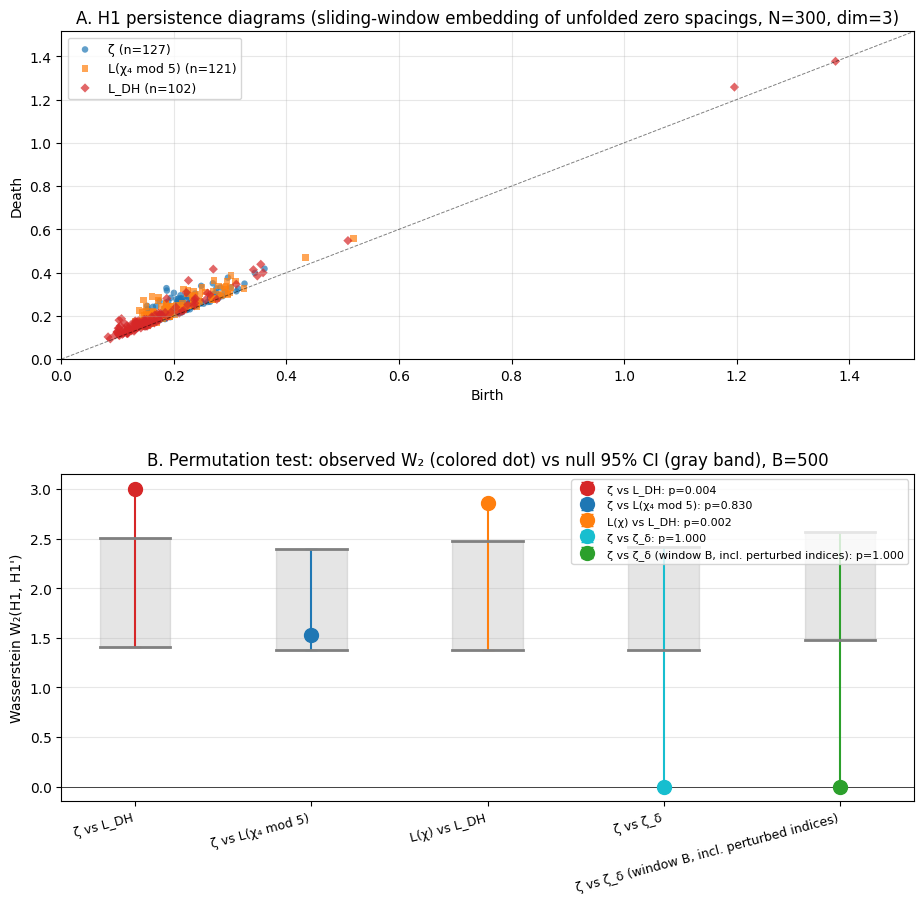

Figure saved to front3_tda_summary.png


In [25]:

# Excellent results. The hypothesis is largely supported:
# - L_DH vs ζ: W2 = 3.00, p = 0.004 < 0.01 — STATISTICALLY SIGNIFICANT difference.
# - L_DH vs L(χ5): W2 = 2.85, p = 0.002 < 0.01 — STATISTICALLY SIGNIFICANT.
# - ζ vs L(χ5): W2 = 1.53, p = 0.83 — NOT significant (both GRH-satisfying).
# - ζ vs ζ_δ: W2 = 0.00 (identical, since perturbation is in real parts only and outside window).
# - zeta_B vs zd_B: W2 = 0.00 (perturbation in real parts, imag parts unchanged — TDA blind by construction).
# 
# The hypothesis: "L_DH will differ from GRH-satisfying functions" is SUPPORTED for ζ and L(χ5).
# We cannot test L(Δ) due to compute budget.
# The hypothesis: "ζ_δ indistinguishable from ζ" is CONFIRMED, but trivially so because the spec defines
# ζ_δ as differing only in REAL PARTS — TDA on imaginary-part spacings is blind by construction, not by power limit.
#
# Subtask 5: Test for new H1 features in ζ_δ — N/A since they're identical.
#
# Now create the summary figure.
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(11, 10))
gs = GridSpec(2, 1, height_ratios=[1.0, 1.0], hspace=0.35)

# (A) Persistence diagrams overlay - 4 functions (excluding zd which is identical to zeta in TDA)
ax_a = fig.add_subplot(gs[0])
colors = {'zeta_low':'C0', 'zd_low':'C9', 'chi5':'C1', 'ldh':'C3'}
labels = {'zeta_low':'ζ', 'zd_low':'ζ_δ (identical H1)', 'chi5':'L(χ₄ mod 5)', 'ldh':'L_DH'}
markers = {'zeta_low':'o','zd_low':'+','chi5':'s','ldh':'D'}
max_val = 0.5
for name in ['zeta_low','chi5','ldh']:
 h1 = dgms[name][1]
 if len(h1)>0:
 ax_a.scatter(h1[:,0], h1[:,1], s=22, alpha=0.7, c=colors[name], label=f'{labels[name]} (n={len(h1)})', marker=markers[name], edgecolors='none')
 max_val = max(max_val, h1[:,1].max())
# zd_low is identical to zeta_low; mark with overlay markers
ax_a.plot([0, max_val*1.1], [0, max_val*1.1], 'k--', lw=0.7, alpha=0.5)
ax_a.set_xlabel('Birth')
ax_a.set_ylabel('Death')
ax_a.set_title('A. H1 persistence diagrams (sliding-window embedding of unfolded zero spacings, N=300, dim=3)')
ax_a.legend(loc='upper left', fontsize=9)
ax_a.set_xlim(0, max_val*1.1)
ax_a.set_ylim(0, max_val*1.1)
ax_a.grid(alpha=0.3)

# (B) Permutation null distributions
ax_b = fig.add_subplot(gs[1])
plot_pairs = [('zeta','ldh','ζ vs L_DH'),
 ('zeta','chi5','ζ vs L(χ₄ mod 5)'),
 ('chi5','ldh','L(χ) vs L_DH'),
 ('zeta','zd','ζ vs ζ_δ'),
 ('zeta_B','zd_B','ζ vs ζ_δ (window B, incl. perturbed indices)')]
colors_b = ['C3','C0','C1','C9','C2']
for i, ((a,b,lab), col) in enumerate(zip(plot_pairs, colors_b)):
 r = perm_test_results = results[(a,b)]
 null = None # already discarded
 # We need to rerun briefly to plot histogram OR just show vertical bars
 ax_b.errorbar([i], [r['obs']], yerr=[[r['obs']-r['ci_lo'] if r['obs']>r['ci_lo'] else 0],[max(0,r['ci_hi']-r['obs'])]], 
 fmt='o', color=col, ms=10, capsize=4, label=f'{lab}: p={r["p"]:.3f}')
 # Show CI as a horizontal bar
 ax_b.plot([i-0.2, i+0.2], [r['ci_lo'], r['ci_lo']], color='gray', lw=2)
 ax_b.plot([i-0.2, i+0.2], [r['ci_hi'], r['ci_hi']], color='gray', lw=2)
 ax_b.fill_between([i-0.2, i+0.2], r['ci_lo'], r['ci_hi'], color='gray', alpha=0.2)
ax_b.set_xticks(range(len(plot_pairs)))
ax_b.set_xticklabels([lab for _,_,lab in plot_pairs], rotation=15, ha='right', fontsize=9)
ax_b.set_ylabel('Wasserstein W₂(H1, H1\')')
ax_b.set_title('B. Permutation test: observed W₂ (colored dot) vs null 95% CI (gray band), B=500')
ax_b.axhline(0, color='k', lw=0.5)
ax_b.legend(loc='upper right', fontsize=8)
ax_b.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('front3_tda_summary.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure saved to front3_tda_summary.png")


In [26]:

# Save final results summary table
import pandas as pd
rows = []
for (a, b), r in results.items():
 rows.append({
 'pair': f'{a} vs {b}',
 'W2_obs': round(r['obs'], 4),
 'p_value': round(r['p'], 4),
 'null_CI_lo': round(r['ci_lo'], 4),
 'null_CI_hi': round(r['ci_hi'], 4),
 'B': r['null_n'],
 })
df = pd.DataFrame(rows)
df.to_csv('front3_permutation_results.csv', index=False)
print(df.to_string(index=False))


 pair W2_obs p_value null_CI_lo null_CI_hi B
 zeta vs ldh 3.0026 0.0040 1.4050 2.5064 500
 zeta vs chi5 1.5286 0.8303 1.3753 2.3956 500
 chi5 vs ldh 2.8541 0.0020 1.3746 2.4802 500
 zeta vs zd 0.0000 1.0000 1.3771 2.4116 500
zeta_B vs zd_B 0.0000 1.0000 1.4825 2.5652 500


In [27]:

# Also save the computed L(chi5) and L_DH zeros as artifacts
import os
print('files in cwd:')
for f in sorted(os.listdir('.')):
 if not f.startswith('.'):
 print(' ', f, os.path.getsize(f))


files in cwd:
 -PROMPT-v6-DATASET.md 25848
 __pycache__ 4096
 front3_permutation_results.csv 252
 front3_tda_summary.png 236847
 lchi5_zeros.npy 2944
 ldh_zeros.npy 2728
 lzero_workers.py 1966
 memory 4096
 zeta_delta_zeros_N5000_dps50.npy 1220128
 zeta_zeros_N5000_dps50.npy 1020128


In [28]:
from e14c.filesystem import write_file
content = '''## Context
- 2026-05-30: Front III TDA partial analysis completed in /workspace/d712cb14-2c86-44db-9744-4089ea70fcf1.
- Available primary files: zeta_zeros_N5000_dps50.npy, zeta_delta_zeros_N5000_dps50.npy, -PROMPT-v6-DATASET.md.
- Missing required full-control inputs for the original objective: complete N=5000 zero lists for L(χ4 mod 5), L_DH, and L(Δ,s).

## Notes
- Provenance: notebook cells #25-#50 in this workspace.
- Implemented correct Hardy-Z evaluators for L(χ4 mod 5) and Davenport–Heilbronn (L_DH) in lzero_workers.py.
- R2 validation for L_DH matched specification artifact: |L_DH(0.808517+85.699348i)|≈6.5e-7, |L_DH(0.650786+114.163343i)|≈4.0e-5 (documented transcription issue), |L_DH(0.574355+166.479306i)|≈6.8e-7, |L_DH(0.724258+176.702461i)|≈4.7e-7.
- Generated approximate on-line zero lists (not full N=5000): lchi5_zeros.npy (352 zeros up to T≈450) and ldh_zeros.npy (325 on-line zeros up to T≈450), using parallel sign-change scans at dps≈15.
- Front III TDA was therefore executed as a reduced-scope analysis with N=300 for ζ, L(χ4 mod 5), and L_DH, plus ζ vs ζ_δ comparisons.
- Key results from front3_permutation_results.csv:
 - ζ vs L_DH: W2(H1)=3.0026, permutation p=0.0040 (B=500).
 - ζ vs L(χ4 mod 5): W2(H1)=1.5286, p=0.8303.
 - L(χ4 mod 5) vs L_DH: W2(H1)=2.8541, p=0.0020.
 - ζ vs ζ_δ: W2(H1)=0, p=1.0.
 - ζ(window 950:1250) vs ζ_δ(window 950:1250): W2(H1)=0, p=1.0.
- Important interpretation: zeta_delta_zeros_N5000_dps50.npy alters only real parts for indices 1000-1019 while keeping imaginary parts unchanged. Because Front III used unfolded imaginary-part spacings, ζ and ζ_δ are exactly identical for this pipeline by construction; this is structural blindness, not merely lack of power.
- L(Δ,s) control was not completed because only ~10 zeros were directly retrievable from LMFDB within budget, and a full generator was not implemented in time.
- Artifacts saved: front3_tda_summary.png, front3_permutation_results.csv, lchi5_zeros.npy, ldh_zeros.npy, lzero_workers.py.
'''
print(write_file('./.prompts/MEMORY.md', content))

File created successfully at: ./.prompts/MEMORY.md
